## Señal de tres tonos con envolventes gaussianas aleatorias

Se desea generar una señal compuesta por tres tonos sinusoidales. Cada tono está multiplicado por una envolvente gaussiana, cuya altura cambia aleatoriamente hasta un 20%. Además, el ancho de banda de cada componente también se define aleatoriamente dentro de un rango establecido.

La señal total se define como:

$$
x(t)=\sum_{k=1}^{3} x_k(t)
$$

donde cada componente está dada por:

$$
x_k(t)=A_k^{(r)}\,g_k(t)\cos(2\pi f_k t)
$$

Por tanto:

$$
x(t)=\sum_{k=1}^{3} A_k^{(r)}\,g_k(t)\cos(2\pi f_k t)
$$

donde:

- $k=1,2,3$ representa cada tono.
- $f_k$ es la frecuencia del tono $k$.
- $A_k^{(r)}$ es la amplitud aleatoria de la envolvente gaussiana.
- $g_k(t)$ es la envolvente gaussiana.
- $x(t)$ es la señal total.

La envolvente gaussiana de cada tono se define como:

$$
g_k(t)=\exp\left(-\frac{(t-t_k)^2}{2(\sigma_k^{(r)})^2}\right)
$$

donde:

- $t_k$ es el instante donde la gaussiana alcanza su valor máximo.
- $\sigma_k^{(r)}$ controla el ancho temporal de la gaussiana.

Cuando $t=t_k$, se tiene:

$$
g_k(t_k)=\exp\left(-\frac{(t_k-t_k)^2}{2(\sigma_k^{(r)})^2}\right)
$$

$$
g_k(t_k)=\exp(0)=1
$$

Por tanto, la gaussiana pura tiene altura máxima igual a 1. La altura real de la componente queda determinada por $A_k^{(r)}$.

La variación aleatoria del 20% en la altura se modela mediante:

$$
A_k^{(r)}=A_k(1+\varepsilon_k)
$$

donde:

$$
\varepsilon_k \sim U(-0.2,0.2)
$$

Esto significa que $\varepsilon_k$ es una variable aleatoria uniforme entre $-0.2$ y $0.2$. Por tanto:

$$
-0.2 \leq \varepsilon_k \leq 0.2
$$

Sumando 1:

$$
0.8 \leq 1+\varepsilon_k \leq 1.2
$$

Multiplicando por $A_k$:

$$
0.8A_k \leq A_k^{(r)} \leq 1.2A_k
$$

Esto significa que la altura de cada gaussiana puede variar entre el 80% y el 120% de su valor nominal.

Además, se define un ancho de banda aleatorio para cada componente. Si $B_k$ es el ancho de banda nominal, entonces:

$$
B_k^{(r)}=B_k(1+\delta_k)
$$

donde:

$$
\delta_k \sim U(-\alpha,\alpha)
$$

Si se desea una variación del 20%, se toma:

$$
\alpha=0.2
$$

Entonces:

$$
\delta_k \sim U(-0.2,0.2)
$$

Por tanto:

$$
0.8B_k \leq B_k^{(r)} \leq 1.2B_k
$$

La relación entre el ancho temporal de una gaussiana y su ancho de banda es inversa. Una gaussiana ancha en el tiempo produce un espectro estrecho en frecuencia. Una gaussiana angosta en el tiempo produce un espectro más ancho en frecuencia.

Conceptualmente:

$$
B_k^{(r)} \propto \frac{1}{\sigma_k^{(r)}}
$$

Por tanto, se puede usar la relación aproximada:

$$
\sigma_k^{(r)}=\frac{C}{B_k^{(r)}}
$$

donde $C$ es una constante que depende de la definición exacta usada para el ancho de banda.

De esta relación se obtiene:

$$
B_k^{(r)} \uparrow \quad \Rightarrow \quad \sigma_k^{(r)} \downarrow
$$

$$
B_k^{(r)} \downarrow \quad \Rightarrow \quad \sigma_k^{(r)} \uparrow
$$

Es decir, si el ancho de banda aumenta, la gaussiana se hace más estrecha en el tiempo. Si el ancho de banda disminuye, la gaussiana se hace más ancha en el tiempo.

Sustituyendo las expresiones anteriores, la señal final queda:

$$
x(t)=\sum_{k=1}^{3}
A_k(1+\varepsilon_k)
\exp\left(-\frac{(t-t_k)^2}{2(\sigma_k^{(r)})^2}\right)
\cos(2\pi f_k t)
$$

con:

$$
\varepsilon_k \sim U(-0.2,0.2)
$$

$$
B_k^{(r)}=B_k(1+\delta_k)
$$

$$
\delta_k \sim U(-\alpha,\alpha)
$$

$$
\sigma_k^{(r)}=\frac{C}{B_k^{(r)}}
$$

En conclusión, esta señal representa tres tonos localizados en el tiempo mediante envolventes gaussianas. La variación aleatoria del 20% en la altura representa cambios de amplitud entre componentes, mientras que la variación aleatoria del ancho de banda representa que cada tono puede ocupar una región diferente en frecuencia. Por esta razón, la señal es útil para estudiar espectro, ancho de banda y comportamiento tiempo-frecuencia de señales multicomponente.

===== PARÁMETROS ALEATORIOS GENERADOS =====

Tono 1
Frecuencia: 100 Hz
Amplitud nominal: 1.00
Amplitud aleatoria: 1.1085
Variación de altura: 10.85%
Ancho de banda nominal: 20.00 Hz
Ancho de banda aleatorio: 22.9856 Hz
Variación de BW: 14.93%
Sigma temporal: 0.006924 s
-------------------------------------------
Tono 2
Frecuencia: 300 Hz
Amplitud nominal: 1.00
Amplitud aleatoria: 0.8083
Variación de altura: -19.17%
Ancho de banda nominal: 40.00 Hz
Ancho de banda aleatorio: 39.9642 Hz
Variación de BW: -0.09%
Sigma temporal: 0.003982 s
-------------------------------------------
Tono 3
Frecuencia: 600 Hz
Amplitud nominal: 1.00
Amplitud aleatoria: 1.0535
Variación de altura: 5.35%
Ancho de banda nominal: 80.00 Hz
Ancho de banda aleatorio: 66.7902 Hz
Variación de BW: -16.51%
Sigma temporal: 0.002383 s
-------------------------------------------


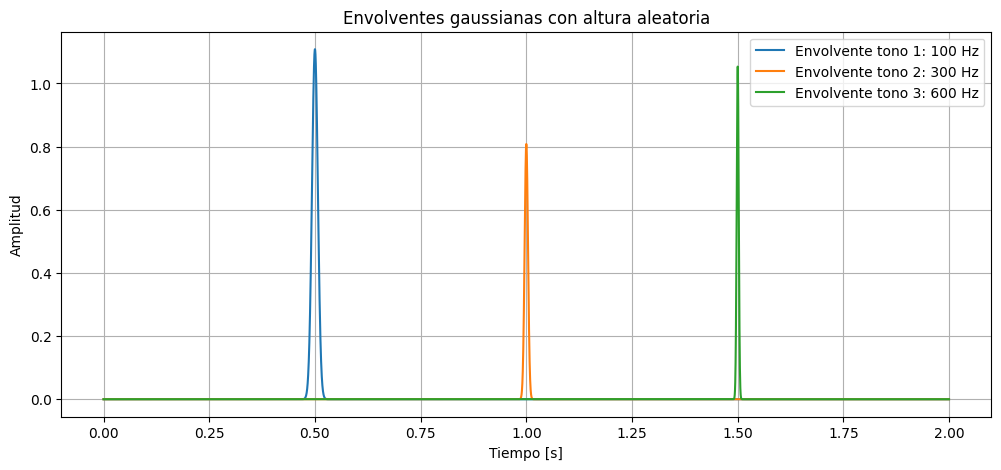

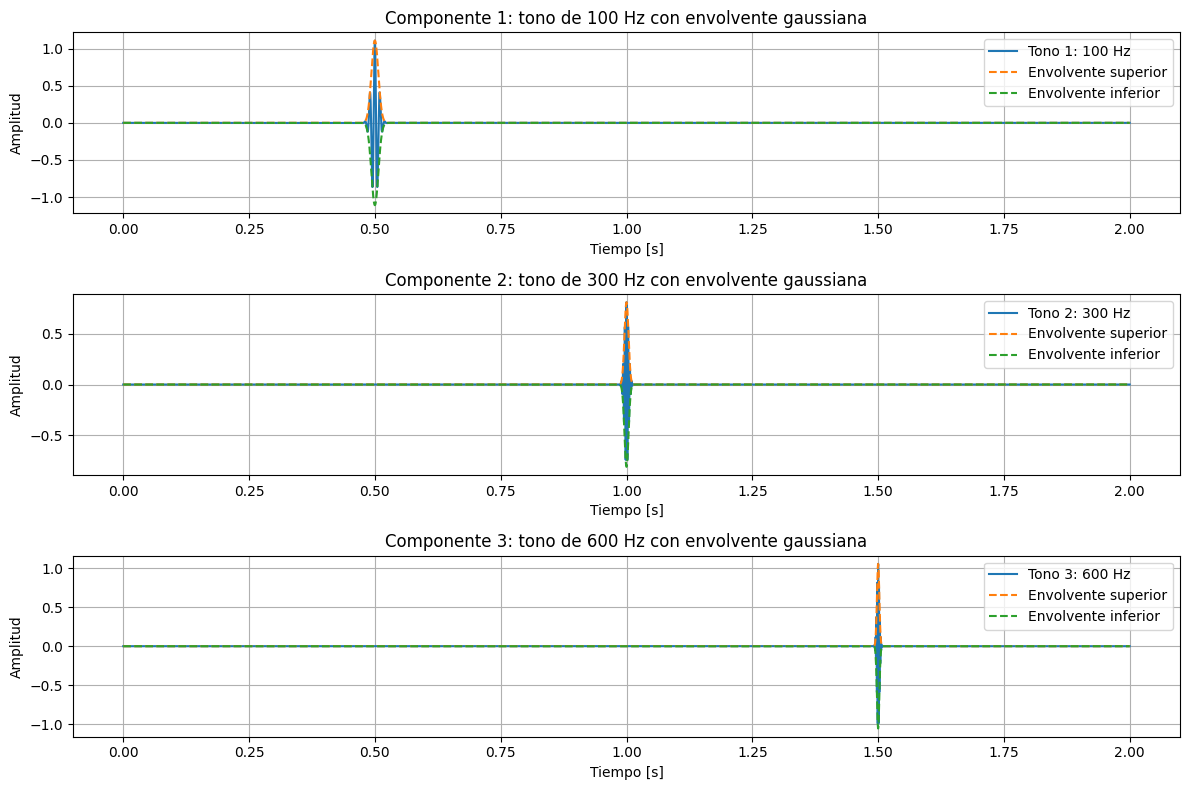

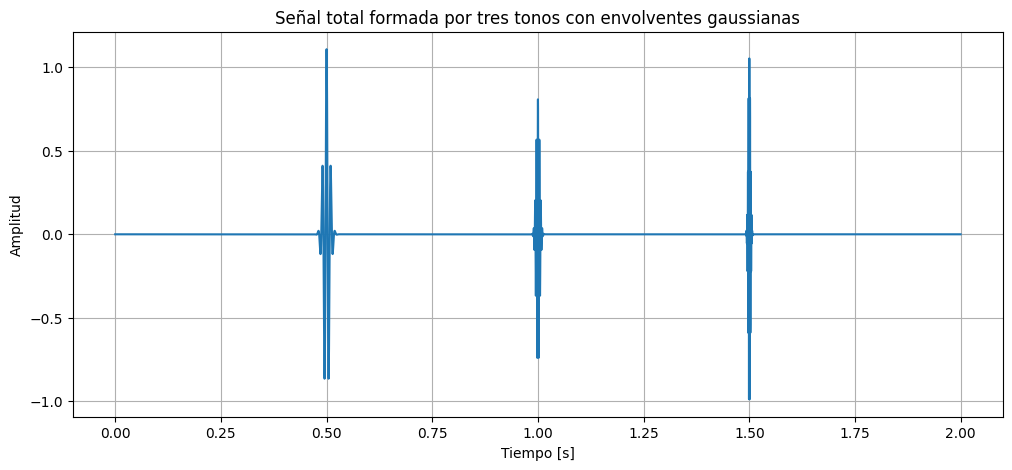

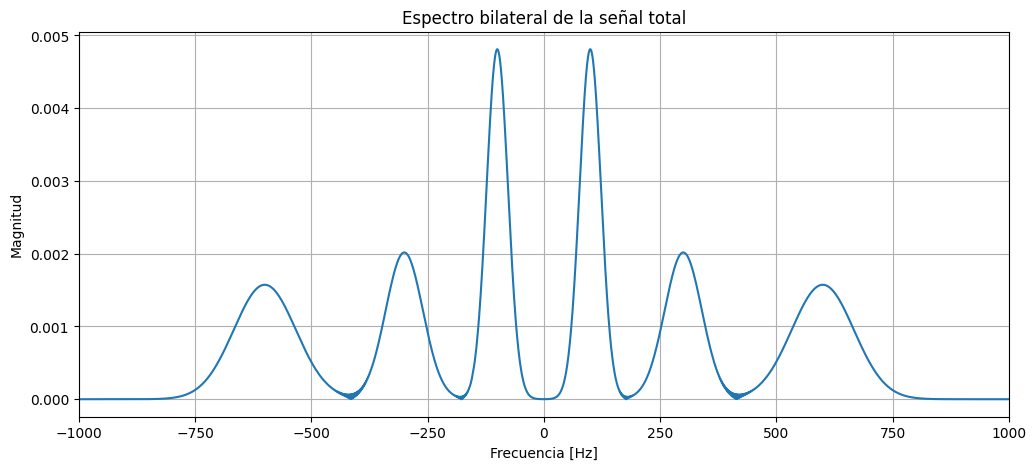

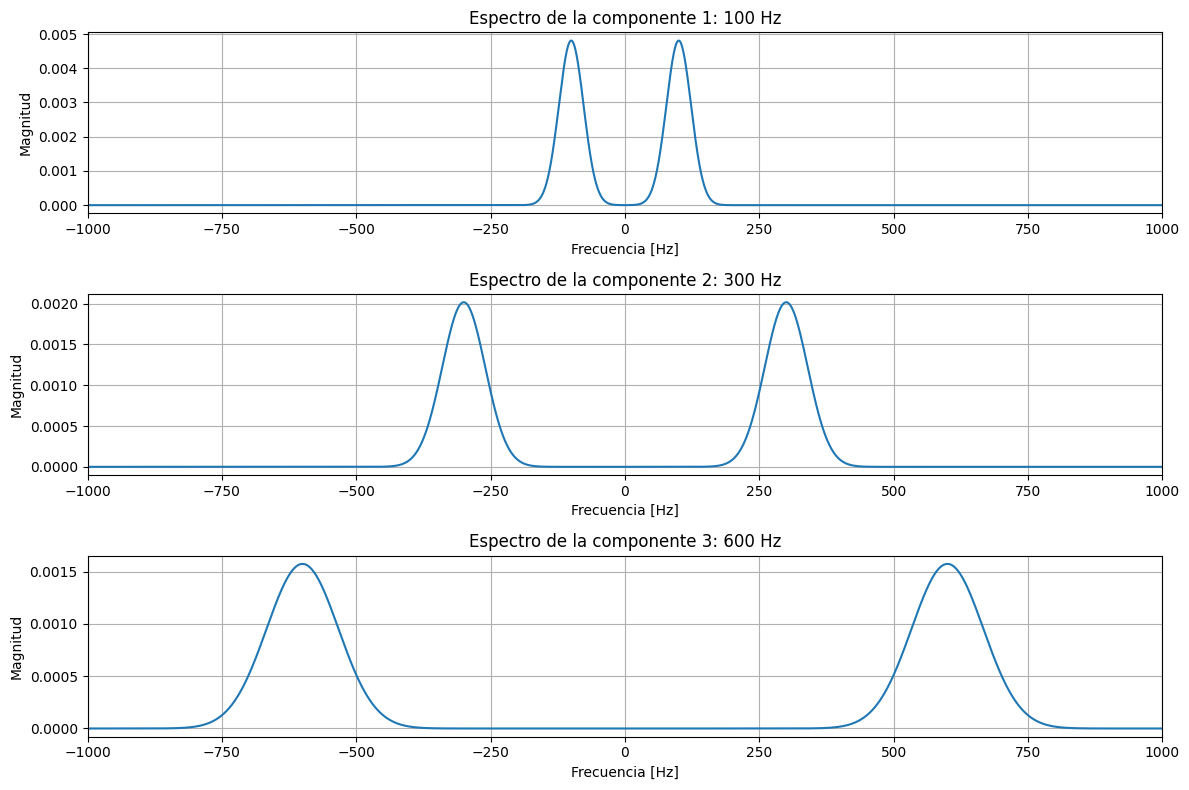

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. CONFIGURACIÓN GENERAL
# ============================================================

np.random.seed(10)  # Semilla para que los resultados sean reproducibles

fs = 5000           # Frecuencia de muestreo [Hz]
T = 2               # Duración total de la señal [s]
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Frecuencias de los tres tonos [Hz]
f_tonos = np.array([100, 300, 600])

# Amplitudes nominales
A_nominal = np.array([1.0, 1.0, 1.0])

# Centros temporales de las gaussianas [s]
t_centros = np.array([0.5, 1.0, 1.5])

# Anchos de banda nominales [Hz]
B_nominal = np.array([20, 40, 80])

# Variación aleatoria máxima
variacion_altura = 0.20      # ±20%
variacion_bw = 0.30          # ±30% para el ancho de banda

# Constante para relacionar ancho de banda y sigma
# Relación aproximada: sigma = C / B
C = 1 / (2*np.pi)

# ============================================================
# 2. PARÁMETROS ALEATORIOS
# ============================================================

# Variación aleatoria de altura: epsilon_k ~ U(-0.2, 0.2)
epsilon = np.random.uniform(-variacion_altura, variacion_altura, size=3)

# Alturas aleatorias
A_random = A_nominal * (1 + epsilon)

# Variación aleatoria del ancho de banda
delta = np.random.uniform(-variacion_bw, variacion_bw, size=3)

# Anchos de banda aleatorios
B_random = B_nominal * (1 + delta)

# Sigma temporal calculado desde el ancho de banda
sigma_random = C / B_random

# ============================================================
# 3. GENERACIÓN DE CADA COMPONENTE
# ============================================================

componentes = []
envolventes = []

for k in range(3):
    # Envolvente gaussiana
    gk = np.exp(-((t - t_centros[k])**2) / (2 * sigma_random[k]**2))
    
    # Tono con envolvente gaussiana
    xk = A_random[k] * gk * np.cos(2*np.pi*f_tonos[k]*t)
    
    envolventes.append(A_random[k] * gk)
    componentes.append(xk)

componentes = np.array(componentes)
envolventes = np.array(envolventes)

# Señal total
x_total = np.sum(componentes, axis=0)

# ============================================================
# 4. MOSTRAR PARÁMETROS GENERADOS
# ============================================================

print("===== PARÁMETROS ALEATORIOS GENERADOS =====\n")

for k in range(3):
    print(f"Tono {k+1}")
    print(f"Frecuencia: {f_tonos[k]} Hz")
    print(f"Amplitud nominal: {A_nominal[k]:.2f}")
    print(f"Amplitud aleatoria: {A_random[k]:.4f}")
    print(f"Variación de altura: {epsilon[k]*100:.2f}%")
    print(f"Ancho de banda nominal: {B_nominal[k]:.2f} Hz")
    print(f"Ancho de banda aleatorio: {B_random[k]:.4f} Hz")
    print(f"Variación de BW: {delta[k]*100:.2f}%")
    print(f"Sigma temporal: {sigma_random[k]:.6f} s")
    print("-------------------------------------------")

# ============================================================
# 5. GRÁFICA DE LAS ENVOLVENTES GAUSSIANAS
# ============================================================

plt.figure(figsize=(12, 5))

for k in range(3):
    plt.plot(t, envolventes[k], label=f"Envolvente tono {k+1}: {f_tonos[k]} Hz")

plt.title("Envolventes gaussianas con altura aleatoria")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# 6. GRÁFICAS DE CADA TONO MODULADO POR SU GAUSSIANA
# ============================================================

plt.figure(figsize=(12, 8))

for k in range(3):
    plt.subplot(3, 1, k+1)
    plt.plot(t, componentes[k], label=f"Tono {k+1}: {f_tonos[k]} Hz")
    plt.plot(t, envolventes[k], '--', label="Envolvente superior")
    plt.plot(t, -envolventes[k], '--', label="Envolvente inferior")
    plt.title(f"Componente {k+1}: tono de {f_tonos[k]} Hz con envolvente gaussiana")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 7. SEÑAL TOTAL EN EL TIEMPO
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(t, x_total)
plt.title("Señal total formada por tres tonos con envolventes gaussianas")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

# ============================================================
# 8. FUNCIÓN PARA CALCULAR ESPECTRO
# ============================================================

def calcular_espectro(x, fs):
    N = len(x)
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))
    X_mag = np.abs(X) / N
    return f, X_mag

# Espectro de la señal total
f, X_total_mag = calcular_espectro(x_total, fs)

# ============================================================
# 9. ESPECTRO DE LA SEÑAL TOTAL
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(f, X_total_mag)
plt.title("Espectro bilateral de la señal total")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(-1000, 1000)
plt.grid(True)
plt.show()

# ============================================================
# 10. ESPECTRO DE CADA COMPONENTE
# ============================================================

plt.figure(figsize=(12, 8))

for k in range(3):
    f, Xk_mag = calcular_espectro(componentes[k], fs)
    plt.subplot(3, 1, k+1)
    plt.plot(f, Xk_mag)
    plt.title(f"Espectro de la componente {k+1}: {f_tonos[k]} Hz")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(-1000, 1000)
    plt.grid(True)

plt.tight_layout()
plt.show()

## Señal PM de banda angosta

Una señal modulada en fase se define como:

$$
s_{PM}(t)=A_c\cos\left(2\pi f_c t+\beta m_n(t)\right)
$$

donde:

- $A_c$ es la amplitud de la portadora.
- $f_c$ es la frecuencia de la portadora.
- $m_n(t)$ es la señal moduladora normalizada.
- $\beta$ es el índice de modulación de fase.

Para que la señal sea de **banda angosta**, se deben cumplir las condiciones:

$$
|m_n(t)|\leq 1
$$

$$
\beta \ll 1
$$

y la portadora debe estar suficientemente separada del mensaje:

$$
f_c \gg B_m
$$

donde $B_m$ es el ancho de banda de la señal moduladora.

La señal moduladora puede ser, por ejemplo:

$$
m_n(t)=\cos(2\pi f_m t)
$$

Entonces la señal PM queda:

$$
s_{PM}(t)=A_c\cos\left(2\pi f_c t+\beta \cos(2\pi f_m t)\right)
$$

Como se trabaja en banda angosta, se usa la aproximación de ángulo pequeño:

$$
\cos(\beta m_n(t))\approx 1
$$

$$
\sin(\beta m_n(t))\approx \beta m_n(t)
$$

Aplicando la identidad:

$$
\cos(a+b)=\cos(a)\cos(b)-\sin(a)\sin(b)
$$

se obtiene:

$$
s_{PM}(t)\approx A_c\cos(2\pi f_c t)
-
A_c\beta m_n(t)\sin(2\pi f_c t)
$$

Esta expresión muestra que la señal PM de banda angosta tiene una portadora dominante y una componente proporcional al mensaje en cuadratura.

Si:

$$
m_n(t)=\cos(2\pi f_m t)
$$

entonces:

$$
s_{PM}(t)\approx A_c\cos(2\pi f_c t)
-
A_c\beta \cos(2\pi f_m t)\sin(2\pi f_c t)
$$

Usando:

$$
\cos(a)\sin(b)=\frac{1}{2}\left[\sin(b+a)+\sin(b-a)\right]
$$

se obtiene:

$$
s_{PM}(t)\approx A_c\cos(2\pi f_c t)
-
\frac{A_c\beta}{2}\sin(2\pi(f_c+f_m)t)
-
\frac{A_c\beta}{2}\sin(2\pi(f_c-f_m)t)
$$

Por tanto, en banda angosta aparecen principalmente tres componentes:

$$
f_c
$$

$$
f_c+f_m
$$

$$
f_c-f_m
$$

El ancho de banda aproximado se calcula como:

$$
B_{PM,NB}=(f_c+f_m)-(f_c-f_m)
$$

Por tanto:

$$
B_{PM,NB}=2f_m
$$

Si la señal moduladora tiene varios tonos, el ancho de banda se toma con la frecuencia máxima del mensaje:

$$
B_m=f_{\max}
$$

y entonces:

$$
B_{PM,NB}\approx 2B_m
$$

En resumen, para generar una PM de banda angosta se debe usar:

$$
s_{PM,NB}(t)=A_c\cos\left(2\pi f_c t+\beta m_n(t)\right)
$$

cumpliendo:

$$
\beta \ll 1
$$

$$
|m_n(t)|\leq 1
$$

$$
f_c \gg B_m
$$

y el ancho de banda aproximado es:

$$
B_{PM,NB}\approx 2B_m
$$

===== CONDICIONES PM DE BANDA ANGOSTA =====
Amplitud portadora Ac = 1.0
Frecuencia portadora fc = 1000 Hz
Frecuencia moduladora fm = 100 Hz
Índice de modulación beta = 0.15
Condición beta << 1: Cumple
Condición fc >> Bm: Cumple
Ancho de banda del mensaje Bm = 100 Hz
Ancho de banda PM banda angosta ≈ 2Bm = 200 Hz
Componentes principales: fc-fm = 900 Hz, fc = 1000 Hz, fc+fm = 1100 Hz


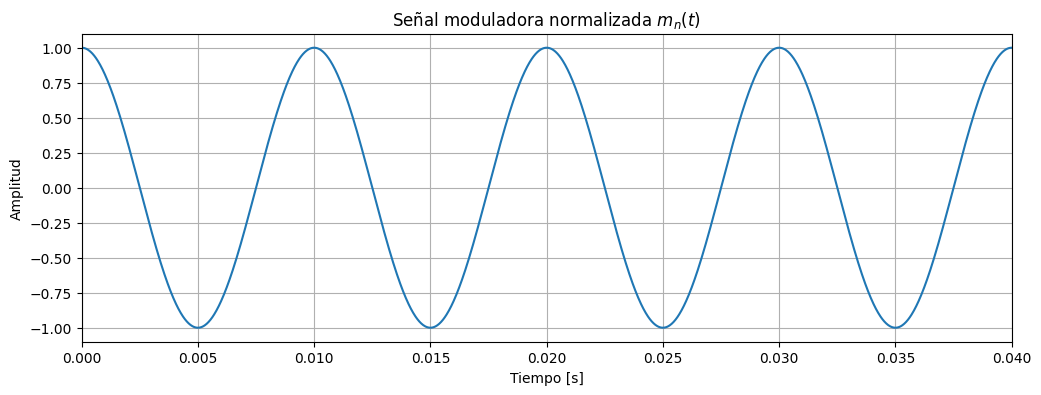

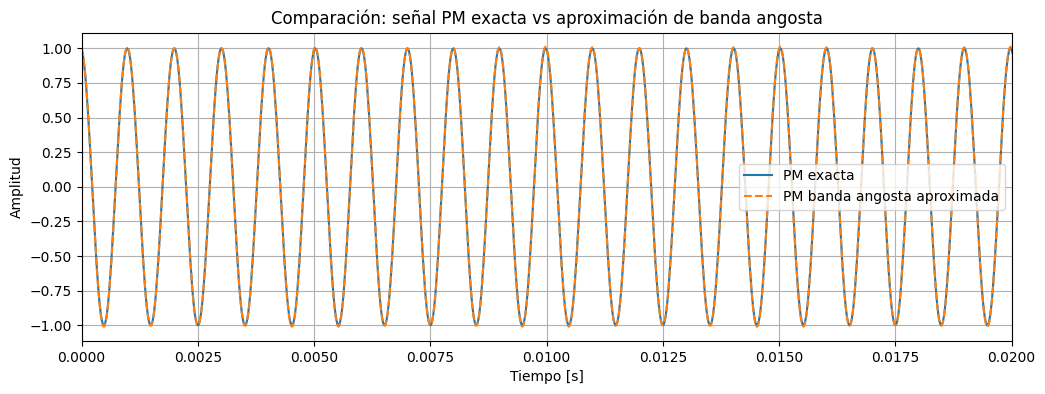

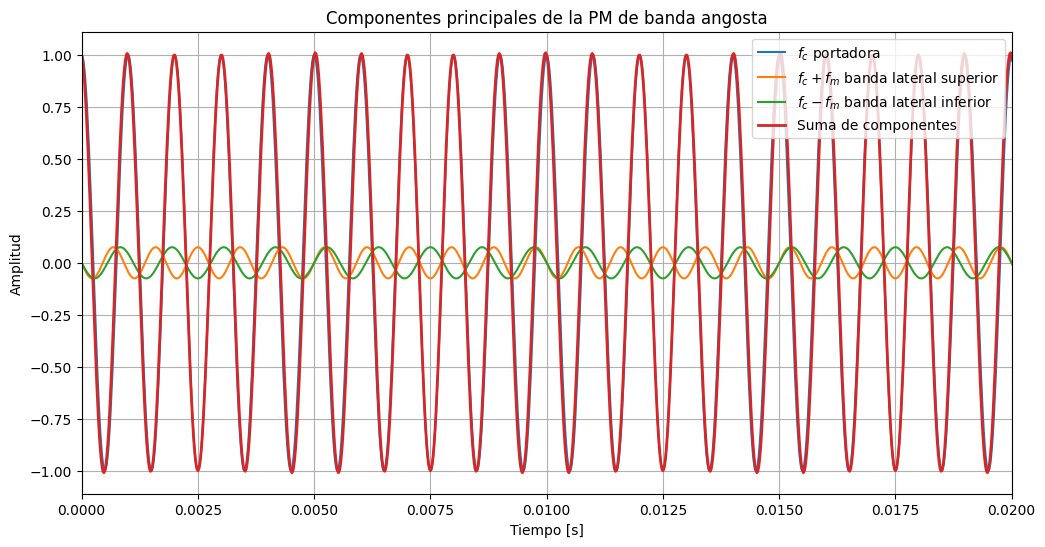

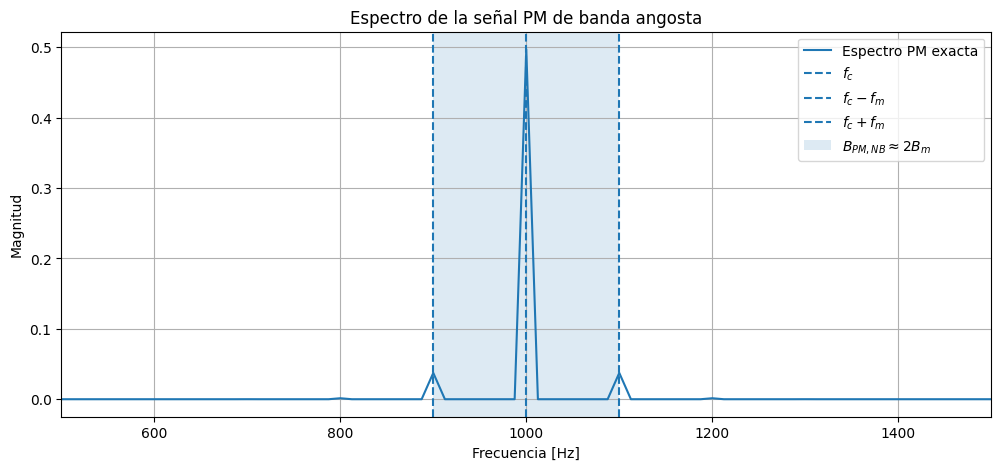

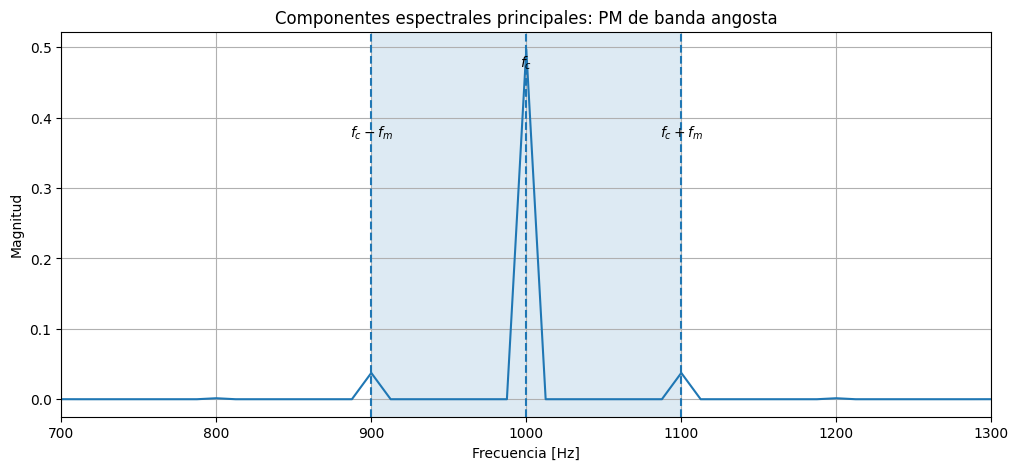

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. PARÁMETROS DE LA SEÑAL PM DE BANDA ANGOSTA
# ============================================================

Ac = 1.0              # Amplitud de la portadora
fc = 1000             # Frecuencia de portadora [Hz]
fm = 100              # Frecuencia del mensaje [Hz]
beta = 0.15           # Índice de modulación de fase, beta << 1

fs = 50000            # Frecuencia de muestreo [Hz]
T = 0.08              # Duración de la simulación [s]
t = np.arange(0, T, 1/fs)

# ============================================================
# 2. CONDICIONES DE BANDA ANGOSTA
# ============================================================

Bm = fm
B_PM_NB = 2 * Bm

print("===== CONDICIONES PM DE BANDA ANGOSTA =====")
print(f"Amplitud portadora Ac = {Ac}")
print(f"Frecuencia portadora fc = {fc} Hz")
print(f"Frecuencia moduladora fm = {fm} Hz")
print(f"Índice de modulación beta = {beta}")
print(f"Condición beta << 1: {'Cumple' if beta < 0.3 else 'No cumple'}")
print(f"Condición fc >> Bm: {'Cumple' if fc > 5*Bm else 'No cumple'}")
print(f"Ancho de banda del mensaje Bm = {Bm} Hz")
print(f"Ancho de banda PM banda angosta ≈ 2Bm = {B_PM_NB} Hz")
print(f"Componentes principales: fc-fm = {fc-fm} Hz, fc = {fc} Hz, fc+fm = {fc+fm} Hz")

# ============================================================
# 3. SEÑAL MODULADORA NORMALIZADA
# ============================================================

mn = np.cos(2*np.pi*fm*t)

# ============================================================
# 4. SEÑAL PM EXACTA
# ============================================================

s_pm = Ac * np.cos(2*np.pi*fc*t + beta*mn)

# ============================================================
# 5. APROXIMACIÓN DE BANDA ANGOSTA
# ============================================================
# s_PM(t) ≈ Ac cos(2πfct) - Ac beta mn(t) sin(2πfct)

portadora = Ac * np.cos(2*np.pi*fc*t)
termino_cuadratura = -Ac * beta * mn * np.sin(2*np.pi*fc*t)
s_pm_nb = portadora + termino_cuadratura

# ============================================================
# 6. COMPONENTES TEÓRICAS PRINCIPALES
# ============================================================
# Para mn(t)=cos(2πfmt):
#
# s_PM(t) ≈ Ac cos(2πfct)
# - Ac beta/2 sin(2π(fc+fm)t)
# - Ac beta/2 sin(2π(fc-fm)t)

comp_fc = Ac * np.cos(2*np.pi*fc*t)
comp_usb = -(Ac*beta/2) * np.sin(2*np.pi*(fc+fm)*t)
comp_lsb = -(Ac*beta/2) * np.sin(2*np.pi*(fc-fm)*t)

s_componentes = comp_fc + comp_usb + comp_lsb

# ============================================================
# 7. GRÁFICAS EN EL TIEMPO
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(t, mn)
plt.title("Señal moduladora normalizada $m_n(t)$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.xlim(0, 0.04)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t, s_pm, label="PM exacta")
plt.plot(t, s_pm_nb, "--", label="PM banda angosta aproximada")
plt.title("Comparación: señal PM exacta vs aproximación de banda angosta")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.xlim(0, 0.02)
plt.show()

plt.figure(figsize=(12, 6))

plt.plot(t, comp_fc, label="$f_c$ portadora")
plt.plot(t, comp_usb, label="$f_c+f_m$ banda lateral superior")
plt.plot(t, comp_lsb, label="$f_c-f_m$ banda lateral inferior")
plt.plot(t, s_componentes, linewidth=2, label="Suma de componentes")

plt.title("Componentes principales de la PM de banda angosta")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.xlim(0, 0.02)
plt.show()

# ============================================================
# 8. FUNCIÓN PARA CALCULAR ESPECTRO
# ============================================================

def espectro(x, fs):
    N = len(x)
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))
    mag = np.abs(X) / N
    return f, mag

f, S_mag = espectro(s_pm, fs)

# ============================================================
# 9. ESPECTRO CON COMPONENTES MARCADAS
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(f, S_mag, label="Espectro PM exacta")

# Líneas verticales para marcar las componentes principales
plt.axvline(fc, linestyle="--", label="$f_c$")
plt.axvline(fc-fm, linestyle="--", label="$f_c-f_m$")
plt.axvline(fc+fm, linestyle="--", label="$f_c+f_m$")

plt.axvline(-(fc), linestyle=":")
plt.axvline(-(fc-fm), linestyle=":")
plt.axvline(-(fc+fm), linestyle=":")

# Región aproximada de ancho de banda positivo
plt.axvspan(fc-Bm, fc+Bm, alpha=0.15, label="$B_{PM,NB}\\approx 2B_m$")

plt.title("Espectro de la señal PM de banda angosta")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid(True)
plt.legend()
plt.xlim(500, 1500)
plt.show()

# ============================================================
# 10. ZOOM DEL ESPECTRO POSITIVO
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(f, S_mag)

plt.axvline(fc-fm, linestyle="--")
plt.axvline(fc, linestyle="--")
plt.axvline(fc+fm, linestyle="--")

plt.text(fc-fm, max(S_mag)*0.75, "$f_c-f_m$", ha="center")
plt.text(fc, max(S_mag)*0.95, "$f_c$", ha="center")
plt.text(fc+fm, max(S_mag)*0.75, "$f_c+f_m$", ha="center")

plt.axvspan(fc-Bm, fc+Bm, alpha=0.15)

plt.title("Componentes espectrales principales: PM de banda angosta")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid(True)
plt.xlim(fc - 3*fm, fc + 3*fm)
plt.show()

## PM de banda angosta con ruido y demodulación coherente

Partimos de una señal PM de banda angosta:

$$
s_{PM}(t)=A_c\cos\left(2\pi f_c t+\beta m_n(t)\right)
$$

donde se cumple:

$$
|m_n(t)|\leq 1
$$

$$
\beta \ll 1
$$

$$
f_c \gg B_m
$$

Para PM de banda angosta, se usa la aproximación:

$$
s_{PM}(t)\approx A_c\cos(2\pi f_c t)-A_c\beta m_n(t)\sin(2\pi f_c t)
$$

Esta aproximación coincide con el cuaderno de PM: la señal queda formada por una portadora dominante y un término de bandas laterales proporcional a $m_n(t)$. :contentReference[oaicite:0]{index=0}

---

### Señal con ruido AWGN

Al pasar por un canal con ruido gaussiano aditivo, la señal recibida es:

$$
r(t)=s_{PM}(t)+n_c(t)
$$

donde:

$$
n_c(t)\sim \mathcal{N}(0,\sigma_c^2)
$$

Entonces:

$$
r(t)=A_c\cos(2\pi f_c t)-A_c\beta m_n(t)\sin(2\pi f_c t)+n_c(t)
$$

El modelo AWGN usado es el mismo del documento experimental, donde la señal recibida se representa como señal transmitida más ruido gaussiano aditivo. :contentReference[oaicite:1]{index=1}

---

### Demodulación coherente con desfase cero

Como el desfase de la portadora de recepción es cero, el receptor está perfectamente sincronizado. Para recuperar el mensaje en PM de banda angosta se multiplica por una portadora local en cuadratura:

$$
c_L(t)=-2\sin(2\pi f_c t)
$$

La señal después del mezclador es:

$$
y(t)=r(t)c_L(t)
$$

Sustituyendo:

$$
y(t)=
\left[
A_c\cos(2\pi f_c t)
-
A_c\beta m_n(t)\sin(2\pi f_c t)
+
n_c(t)
\right]
[-2\sin(2\pi f_c t)]
$$

Distribuyendo:

$$
y(t)=
-2A_c\cos(2\pi f_c t)\sin(2\pi f_c t)
+
2A_c\beta m_n(t)\sin^2(2\pi f_c t)
-
2n_c(t)\sin(2\pi f_c t)
$$

Usando:

$$
2\sin(a)\cos(a)=\sin(2a)
$$

y:

$$
\sin^2(a)=\frac{1-\cos(2a)}{2}
$$

se obtiene:

$$
y(t)=
-A_c\sin(4\pi f_c t)
+
A_c\beta m_n(t)
-
A_c\beta m_n(t)\cos(4\pi f_c t)
-
2n_c(t)\sin(2\pi f_c t)
$$

---

### Filtrado pasa bajas

Después del mezclador se aplica un filtro pasa bajas. Este elimina las componentes de alta frecuencia:

$$
-A_c\sin(4\pi f_c t)
$$

y:

$$
-A_c\beta m_n(t)\cos(4\pi f_c t)
$$

Por tanto, queda:

$$
y_{LPF}(t)=A_c\beta m_n(t)+\tilde{n}(t)
$$

donde:

$$
\tilde{n}(t)=LPF\{-2n_c(t)\sin(2\pi f_c t)\}
$$

es el ruido trasladado a banda base.

Este resultado es coherente con la demodulación coherente del documento experimental: cuando el error de fase es cero, la recuperación es óptima y no aparece atenuación por $\cos(\phi)$. :contentReference[oaicite:2]{index=2}

---

### Señal recuperada

Para recuperar una versión normalizada del mensaje, se divide entre $A_c\beta$:

$$
\hat{m}_n(t)=\frac{y_{LPF}(t)}{A_c\beta}
$$

Sustituyendo:

$$
\hat{m}_n(t)=m_n(t)+\frac{\tilde{n}(t)}{A_c\beta}
$$

Por tanto, con desfase cero:

$$
\boxed{
\hat{m}_n(t)=m_n(t)+\text{ruido en banda base}
}
$$

La señal útil se recupera sin atenuación de fase. El único error restante proviene del ruido del canal.

===== DEMODULACIÓN COHERENTE CON RUIDO =====

Parámetros del sistema:
Portadora: fc = 1000 Hz, Ac = 1.0
Moduladora: fm = 100 Hz
Índice PM: β = 0.15
Duración: T = 0.08 s
Frecuencia muestreo: fs = 50000 Hz

SNR deseada: 30 dB
Potencia señal: 0.505625
Potencia ruido: 0.000506
Desviación estándar del ruido: 0.022486



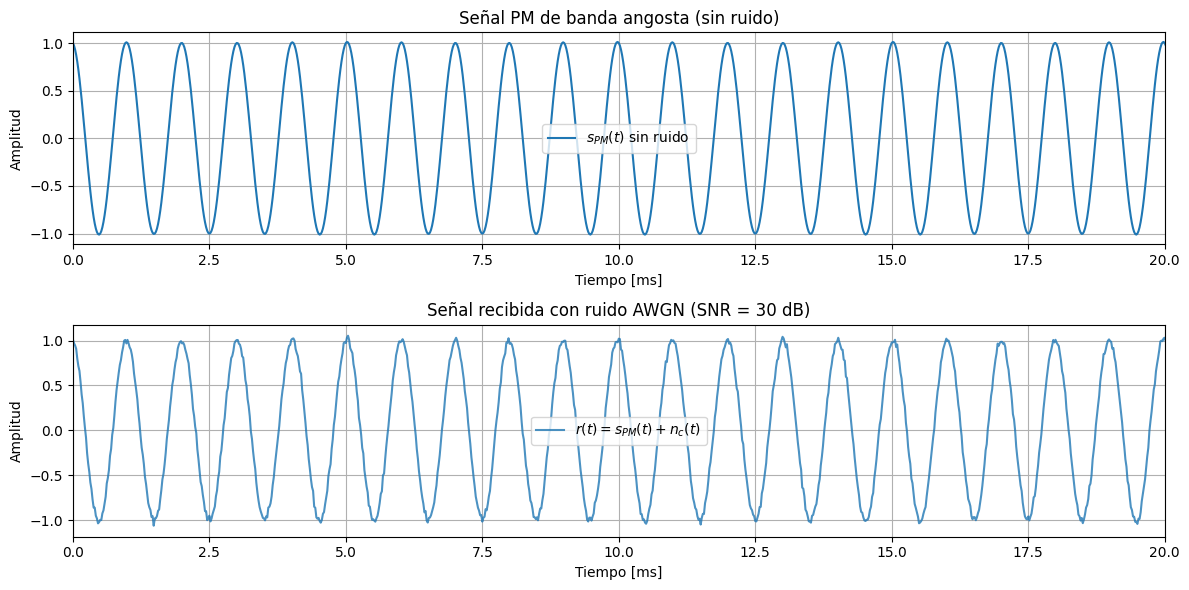

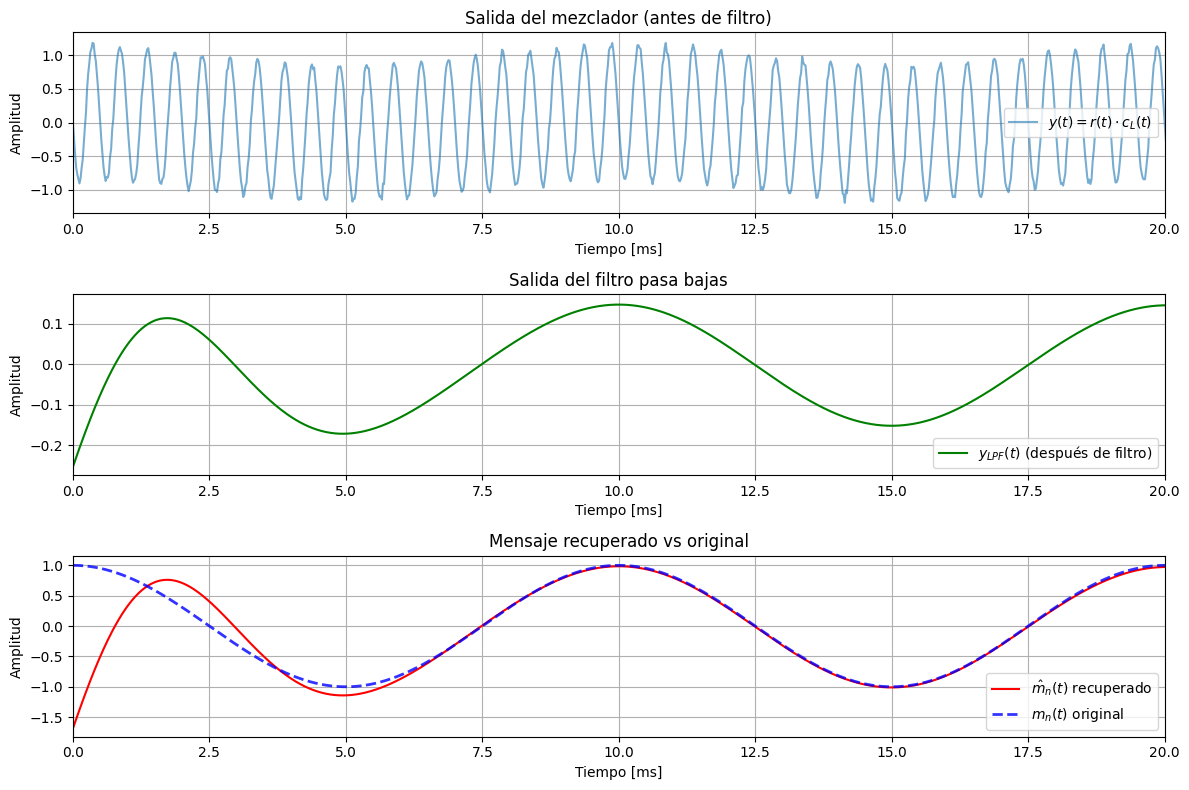

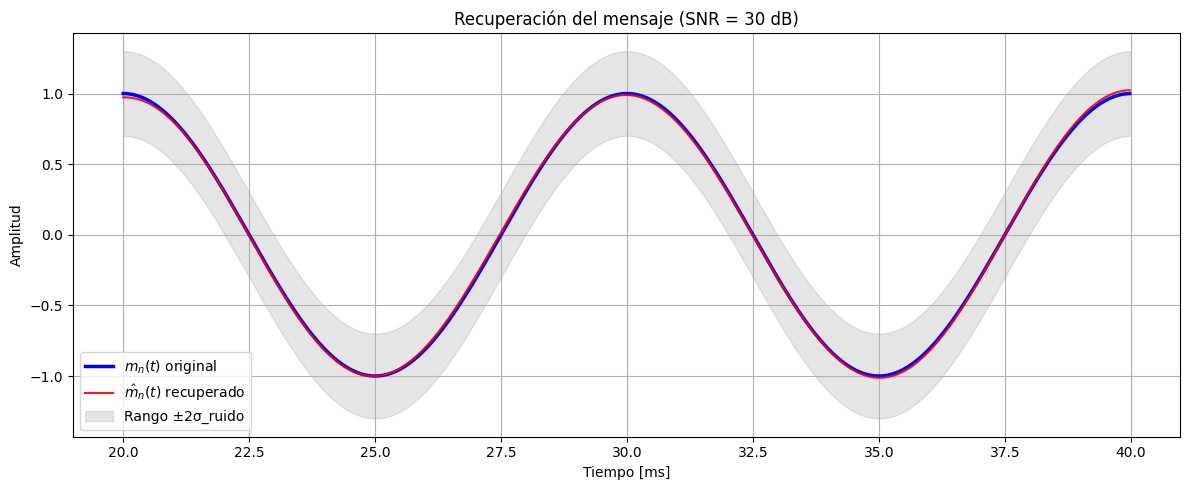

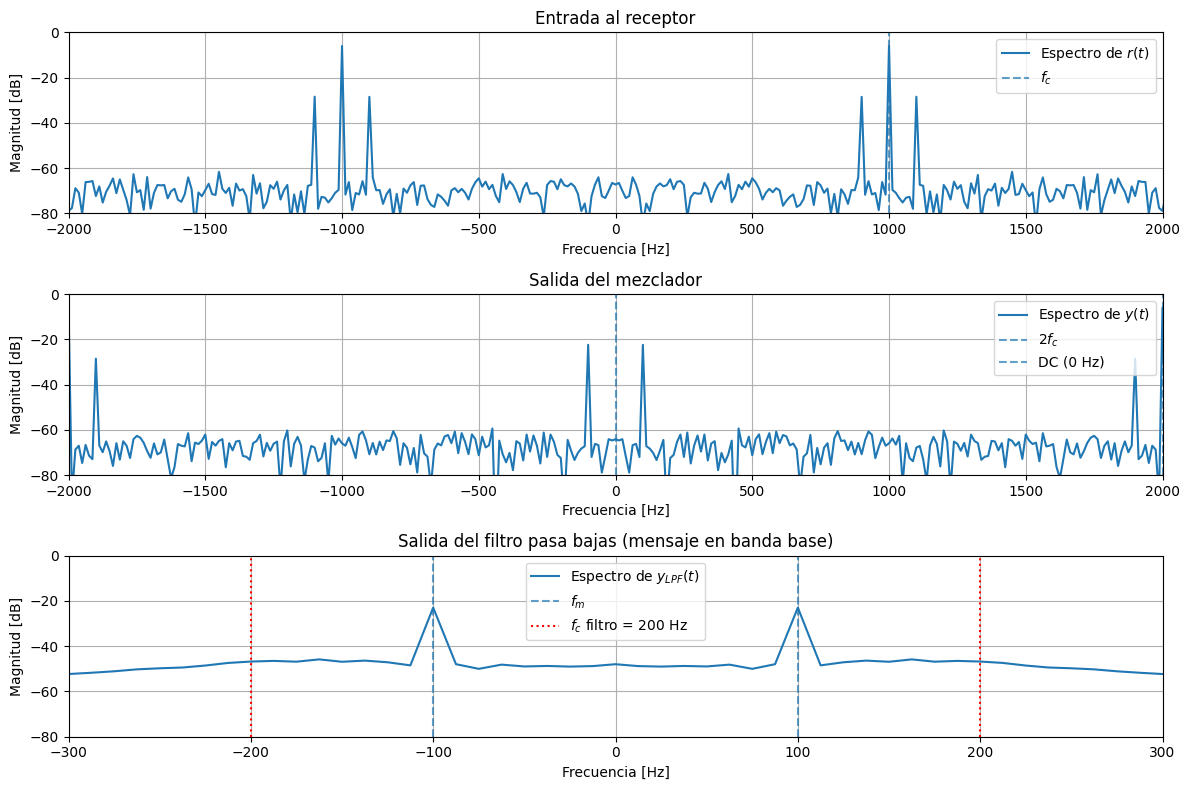


===== RESULTADOS DE DEMODULACIÓN =====

SNR de entrada: 30 dB
Potencia señal original: 0.505625
Potencia ruido de entrada: 0.000506
Potencia ruido en banda base: 0.042678
MSE (Error cuadrático medio): 0.042678
RMSE: 0.206586
SNR de salida: 10.69 dB

Conclusión: Con desfase cero, el mensaje se recupera SIN atenuación.
El ruido en banda base es proporcional al ruido de entrada.


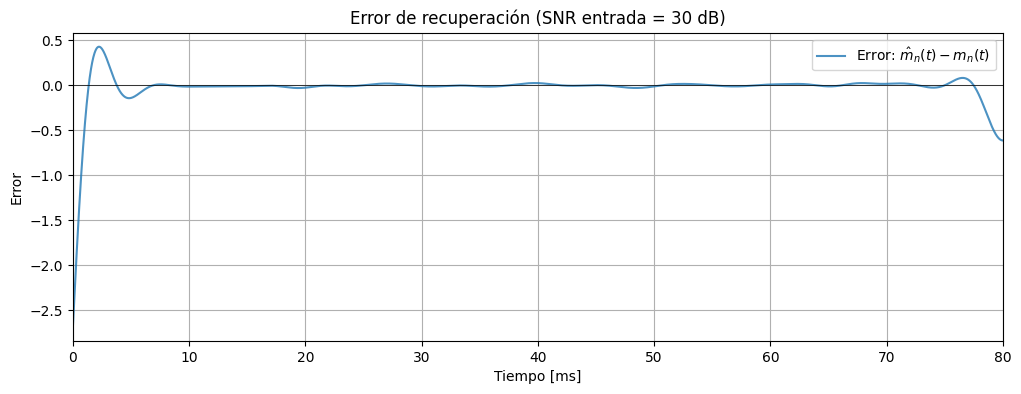

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ============================================================
# 1. REUTILIZAR PARÁMETROS DEL SISTEMA PM DE BANDA ANGOSTA
# ============================================================

# Los parámetros ya están en el kernel del cuaderno anterior
# Ac, fc, fm, beta, fs, T, t, mn, s_pm_nb

print("===== DEMODULACIÓN COHERENTE CON RUIDO =====\n")
print(f"Parámetros del sistema:")
print(f"Portadora: fc = {fc} Hz, Ac = {Ac}")
print(f"Moduladora: fm = {fm} Hz")
print(f"Índice PM: β = {beta}")
print(f"Duración: T = {T} s")
print(f"Frecuencia muestreo: fs = {fs} Hz\n")

# ============================================================
# 2. DEFINIR NIVEL DE RUIDO (SNR = 30 dB)
# ============================================================

# Potencia de la señal PM
P_signal = np.mean(s_pm_nb**2)

# SNR deseada = 30 dB
SNR_dB = 30
SNR_linear = 10**(SNR_dB/10)
P_noise = P_signal / SNR_linear
sigma_c = np.sqrt(P_noise)

print(f"SNR deseada: {SNR_dB} dB")
print(f"Potencia señal: {P_signal:.6f}")
print(f"Potencia ruido: {P_noise:.6f}")
print(f"Desviación estándar del ruido: {sigma_c:.6f}\n")

# ============================================================
# 3. GENERAR SEÑAL CON RUIDO AWGN
# ============================================================

# Ruido gaussiano aditivo
np.random.seed(42)  # Para reproducibilidad
n_c = np.random.normal(0, sigma_c, len(t))

# Señal recibida: r(t) = s_PM(t) + n_c(t)
r = s_pm_nb + n_c

# ============================================================
# 4. DEMODULADOR COHERENTE - MEZCLADOR EN CUADRATURA
# ============================================================

# Portadora local (fase cero, perfectamente sincronizada)
c_L = -2 * np.sin(2*np.pi*fc*t)

# Salida del mezclador: y(t) = r(t) * c_L(t)
y_mixer = r * c_L

# ============================================================
# 5. DISEÑAR FILTRO PASA BAJAS
# ============================================================

# Frecuencia de corte del filtro (entre fm y fc)
fc_filter = 2 * fm  # Hz

# Filtro Butterworth de orden 4
order = 4
b, a = signal.butter(order, fc_filter / (fs/2), btype='low')

# Aplicar filtro pasa bajas
y_lpf = signal.filtfilt(b, a, y_mixer)

# ============================================================
# 6. RECUPERAR EL MENSAJE
# ============================================================

# Desnormalizar dividiendo entre Ac*beta
m_n_recovered = y_lpf / (Ac * beta)

# ============================================================
# 7. GRÁFICAS: SEÑAL ORIGINAL VS CON RUIDO
# ============================================================

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t*1000, s_pm_nb, label="$s_{PM}(t)$ sin ruido", linewidth=1.5)
plt.title("Señal PM de banda angosta (sin ruido)")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.xlim(0, 20)

plt.subplot(2, 1, 2)
plt.plot(t*1000, r, label="$r(t) = s_{PM}(t) + n_c(t)$", alpha=0.8)
plt.title(f"Señal recibida con ruido AWGN (SNR = {SNR_dB} dB)")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.xlim(0, 20)

plt.tight_layout()
plt.show()

# ============================================================
# 8. GRÁFICAS: PROCESO DE DEMODULACIÓN
# ============================================================

plt.figure(figsize=(12, 8))

# Salida del mezclador
plt.subplot(3, 1, 1)
plt.plot(t*1000, y_mixer, alpha=0.6, label="$y(t) = r(t) \\cdot c_L(t)$")
plt.title("Salida del mezclador (antes de filtro)")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.xlim(0, 20)

# Salida del filtro pasa bajas
plt.subplot(3, 1, 2)
plt.plot(t*1000, y_lpf, label="$y_{LPF}(t)$ (después de filtro)", color='green', linewidth=1.5)
plt.title("Salida del filtro pasa bajas")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.xlim(0, 20)

# Mensaje recuperado vs original
plt.subplot(3, 1, 3)
plt.plot(t*1000, m_n_recovered, label="$\\hat{m}_n(t)$ recuperado", color='red', linewidth=1.5)
plt.plot(t*1000, mn, "--", label="$m_n(t)$ original", color='blue', linewidth=2, alpha=0.8)
plt.title("Mensaje recuperado vs original")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.xlim(0, 20)

plt.tight_layout()
plt.show()

# ============================================================
# 9. ZOOM: COMPARACIÓN DETALLADA
# ============================================================

# Ventana de zoom (20-40 ms)
idx_start = int(0.02 * fs)
idx_end = int(0.04 * fs)

plt.figure(figsize=(12, 5))
plt.plot(t[idx_start:idx_end]*1000, mn[idx_start:idx_end],
         'b-', label="$m_n(t)$ original", linewidth=2.5)
plt.plot(t[idx_start:idx_end]*1000, m_n_recovered[idx_start:idx_end],
         'r-', label="$\\hat{m}_n(t)$ recuperado", linewidth=1.5, alpha=0.9)
plt.fill_between(t[idx_start:idx_end]*1000,
                  mn[idx_start:idx_end] - 2*sigma_c/(Ac*beta),
                  mn[idx_start:idx_end] + 2*sigma_c/(Ac*beta),
                  alpha=0.2, color='gray', label="Rango ±2σ_ruido")
plt.title(f"Recuperación del mensaje (SNR = {SNR_dB} dB)")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 10. ANÁLISIS ESPECTRAL
# ============================================================

def espectro_dB(x, fs):
    N = len(x)
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))
    mag_dB = 20*np.log10(np.abs(X)/N + 1e-10)
    return f, mag_dB

f_spec, R_mag_dB = espectro_dB(r, fs)
f_spec, Y_mixer_mag_dB = espectro_dB(y_mixer, fs)
f_spec, Y_lpf_mag_dB = espectro_dB(y_lpf, fs)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(f_spec, R_mag_dB, label="Espectro de $r(t)$")
plt.axvline(fc, linestyle="--", alpha=0.7, label="$f_c$")
plt.title("Entrada al receptor")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(-2000, 2000)
plt.ylim(-80, 0)
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(f_spec, Y_mixer_mag_dB, label="Espectro de $y(t)$")
plt.axvline(2*fc, linestyle="--", alpha=0.7, label="$2f_c$")
plt.axvline(0, linestyle="--", alpha=0.7, label="DC (0 Hz)")
plt.title("Salida del mezclador")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(-2000, 2000)
plt.ylim(-80, 0)
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(f_spec, Y_lpf_mag_dB, label="Espectro de $y_{LPF}(t)$")
plt.axvline(fm, linestyle="--", alpha=0.7, label="$f_m$")
plt.axvline(-fm, linestyle="--", alpha=0.7)
plt.axvline(fc_filter, linestyle=":", color='red', label=f"$f_c$ filtro = {fc_filter} Hz")
plt.axvline(-fc_filter, linestyle=":", color='red')
plt.title("Salida del filtro pasa bajas (mensaje en banda base)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(-300, 300)
plt.ylim(-80, 0)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 11. ANÁLISIS DE ERROR Y SNR
# ============================================================

# Error de recuperación
error = m_n_recovered - mn
MSE = np.mean(error**2)
RMSE = np.sqrt(MSE)

# SNR de salida
P_signal_recovered = np.mean(mn**2)
P_noise_recovered = np.mean(error**2)
SNR_out_linear = P_signal_recovered / P_noise_recovered
SNR_out_dB = 10*np.log10(SNR_out_linear)

print("\n===== RESULTADOS DE DEMODULACIÓN =====\n")
print(f"SNR de entrada: {SNR_dB} dB")
print(f"Potencia señal original: {P_signal:.6f}")
print(f"Potencia ruido de entrada: {P_noise:.6f}")
print(f"Potencia ruido en banda base: {P_noise_recovered:.6f}")
print(f"MSE (Error cuadrático medio): {MSE:.6f}")
print(f"RMSE: {RMSE:.6f}")
print(f"SNR de salida: {SNR_out_dB:.2f} dB")
print(f"\nConclusión: Con desfase cero, el mensaje se recupera SIN atenuación.")
print(f"El ruido en banda base es proporcional al ruido de entrada.")

# ============================================================
# 12. GRÁFICA DEL ERROR
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(t*1000, error, label="Error: $\\hat{m}_n(t) - m_n(t)$", alpha=0.8)
plt.axhline(0, color='k', linestyle='-', linewidth=0.5)
plt.title(f"Error de recuperación (SNR entrada = {SNR_dB} dB)")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Error")
plt.grid(True)
plt.legend()
plt.xlim(0, 80)
plt.show()

## Experimento Monte Carlo: PM de banda angosta con AWGN y demodulación coherente

Se desea repetir el experimento 100 veces agregando ruido gaussiano blanco aditivo, AWGN, a una señal PM de banda angosta. La relación señal a ruido usada es:

$$
SNR_{dB}=30\,\text{dB}
$$

La señal PM de banda angosta se define como:

$$
s_{PM}(t)=A_c\cos\left(2\pi f_c t+\beta m_n(t)\right)
$$

donde:

- $A_c$ es la amplitud de la portadora.
- $f_c$ es la frecuencia de la portadora.
- $m_n(t)$ es la señal moduladora normalizada.
- $\beta$ es el índice de modulación de fase.

Para banda angosta se cumple:

$$
\beta \ll 1
$$

por lo tanto:

$$
s_{PM}(t)\approx A_c\cos(2\pi f_c t)-A_c\beta m_n(t)\sin(2\pi f_c t)
$$

---

### Señal recibida con ruido

En cada repetición del experimento se agrega una realización diferente de ruido gaussiano:

$$
r_i(t)=s_{PM}(t)+n_i(t)
$$

donde:

$$
i=1,2,\dots,100
$$

y:

$$
n_i(t)\sim \mathcal{N}(0,\sigma_n^2)
$$

Como:

$$
SNR_{dB}=30\,\text{dB}
$$

entonces:

$$
SNR=10^{SNR_{dB}/10}=10^{30/10}=1000
$$

La relación señal a ruido se define como:

$$
SNR=\frac{P_s}{P_n}
$$

por tanto:

$$
P_n=\frac{P_s}{SNR}
$$

y como el ruido es gaussiano de media cero:

$$
\sigma_n^2=P_n=\frac{P_s}{1000}
$$

donde $P_s$ es la potencia promedio de la señal PM transmitida.

---

### Demodulación coherente con desfase cero

Como el desfase de la portadora de recepción es cero, el receptor está sincronizado:

$$
\phi=0
$$

Para recuperar la información de una PM de banda angosta se multiplica la señal recibida por una portadora local en cuadratura:

$$
c_L(t)=-2\sin(2\pi f_c t)
$$

Entonces:

$$
y_i(t)=r_i(t)c_L(t)
$$

Sustituyendo:

$$
y_i(t)=
\left[
A_c\cos(2\pi f_c t)
-
A_c\beta m_n(t)\sin(2\pi f_c t)
+
n_i(t)
\right]
[-2\sin(2\pi f_c t)]
$$

Distribuyendo:

$$
y_i(t)=
-2A_c\cos(2\pi f_c t)\sin(2\pi f_c t)
+
2A_c\beta m_n(t)\sin^2(2\pi f_c t)
-
2n_i(t)\sin(2\pi f_c t)
$$

Usando:

$$
2\sin(a)\cos(a)=\sin(2a)
$$

y:

$$
\sin^2(a)=\frac{1-\cos(2a)}{2}
$$

se obtiene:

$$
y_i(t)=
-A_c\sin(4\pi f_c t)
+
A_c\beta m_n(t)
-
A_c\beta m_n(t)\cos(4\pi f_c t)
-
2n_i(t)\sin(2\pi f_c t)
$$

Después del filtro pasa bajas se eliminan las componentes de alta frecuencia, quedando:

$$
y_{LPF,i}(t)=A_c\beta m_n(t)+\tilde{n}_i(t)
$$

donde $\tilde{n}_i(t)$ es el ruido trasladado a banda base después de la mezcla y el filtrado.

La señal recuperada se obtiene normalizando por $A_c\beta$:

$$
\hat{m}_{n,i}(t)=\frac{y_{LPF,i}(t)}{A_c\beta}
$$

por tanto:

$$
\hat{m}_{n,i}(t)=m_n(t)+\frac{\tilde{n}_i(t)}{A_c\beta}
$$

---

### Definición del error

El error de recuperación en la repetición $i$ se define como:

$$
e_i(t)=\hat{m}_{n,i}(t)-m_n(t)
$$

Sustituyendo la señal recuperada:

$$
e_i(t)=\frac{\tilde{n}_i(t)}{A_c\beta}
$$

Esto significa que, si no hay desfase de portadora y la aproximación de banda angosta es válida, el error se debe principalmente al ruido del canal después de pasar por el proceso de demodulación.

---

### Media del error

Si cada señal tiene $N$ muestras y el experimento se repite 100 veces, la media estimada del error es:

$$
\mu_e=
\frac{1}{100N}
\sum_{i=1}^{100}
\sum_{n=0}^{N-1}
e_i[n]
$$

Como el ruido AWGN tiene media cero:

$$
\mathbb{E}\{n_i(t)\}=0
$$

se espera que:

$$
\mu_e \approx 0
$$

Esto significa que el error no debería tener sesgo sistemático.

---

### Varianza del error

La varianza estimada del error se calcula como:

$$
\sigma_e^2=
\frac{1}{100N-1}
\sum_{i=1}^{100}
\sum_{n=0}^{N-1}
\left(e_i[n]-\mu_e\right)^2
$$

La varianza mide qué tanto se dispersa el error alrededor de su media.

Como se usa:

$$
SNR=1000
$$

la potencia de ruido agregada es mucho menor que la potencia de la señal:

$$
P_n=\frac{P_s}{1000}
$$

Por eso se espera que la varianza del error sea pequeña.

---

### ¿El error es gaussiano?

El ruido agregado al canal es gaussiano:

$$
n_i(t)\sim \mathcal{N}(0,\sigma_n^2)
$$

Además, la demodulación coherente de banda angosta usa operaciones aproximadamente lineales:

1. Multiplicación por una portadora local.
2. Filtrado pasa bajas.
3. Normalización por una constante.

Una transformación lineal de una variable gaussiana sigue siendo gaussiana. Por eso, teóricamente, el error puede modelarse como:

$$
e_i[n]\sim \mathcal{N}(\mu_e,\sigma_e^2)
$$

con:

$$
\mu_e \approx 0
$$

Sin embargo, experimentalmente se debe comprobar con:

- histograma del error,
- curva normal teórica superpuesta,
- gráfico Q-Q,
- prueba de normalidad.

Si el histograma tiene forma de campana, el Q-Q plot se aproxima a una recta y la prueba de normalidad no rechaza la hipótesis gaussiana, entonces el error puede considerarse aproximadamente gaussiano.

---

### Interpretación final

El experimento consiste en repetir 100 veces la transmisión de una señal PM de banda angosta con ruido AWGN de $30\,\text{dB}$. En cada repetición se demodula coherentemente con desfase cero y se calcula el error entre la señal recuperada y la señal original.

Como el receptor no tiene desfase:

$$
\phi=0
$$

no aparece atenuación por error de fase. Por tanto, el error se debe principalmente al ruido.

Se espera que:

$$
\mu_e \approx 0
$$

y que el error tenga comportamiento aproximadamente gaussiano:

$$
e[n]\sim \mathcal{N}(\mu_e,\sigma_e^2)
$$

La varianza $\sigma_e^2$ se estima experimentalmente usando todas las muestras de las 100 repeticiones.

===== CONDICIONES PM DE BANDA ANGOSTA =====
beta = 0.15
Condición beta << 1: Cumple
fc = 1000 Hz
Bm = 100 Hz
Condición fc >> Bm: Cumple
Ancho de banda PM banda angosta ≈ 2Bm = 200 Hz

===== PARÁMETROS DE RUIDO AWGN =====
SNR = 30 dB
SNR lineal = 1000.00
Potencia de señal Ps = 0.500000
Potencia de ruido Pn = 0.00050000
Desviación estándar del ruido sigma_n = 0.02236068

===== ESTADÍSTICAS DEL ERROR =====
Número de experimentos = 100
Número de muestras por experimento = 5000
Número total de muestras de error = 500000
Media del error = -8.82639327e-03
Varianza del error = 2.37060745e-02
Desviación estándar del error = 1.53967771e-01

===== PRUEBA DE NORMALIDAD SHAPIRO-WILK =====
Estadístico = 0.250548
p-value = 0.000000
Resultado: Se rechaza la hipótesis de normalidad.
El error no se comporta perfectamente como gaussiano.


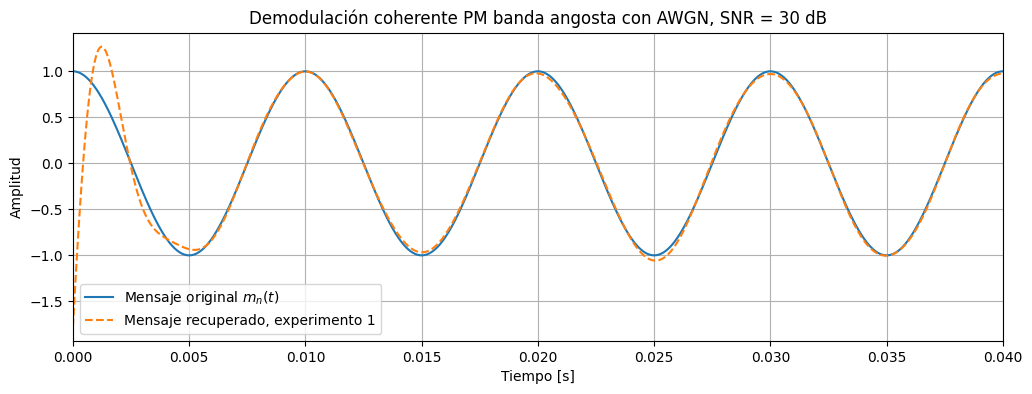

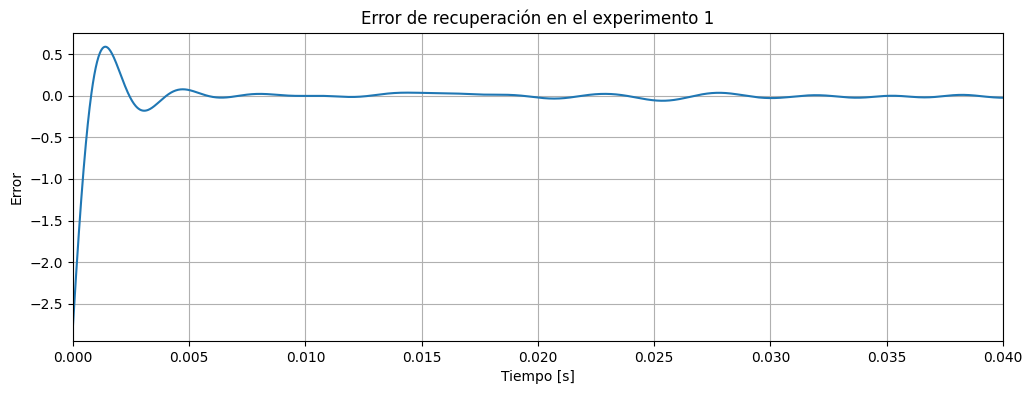

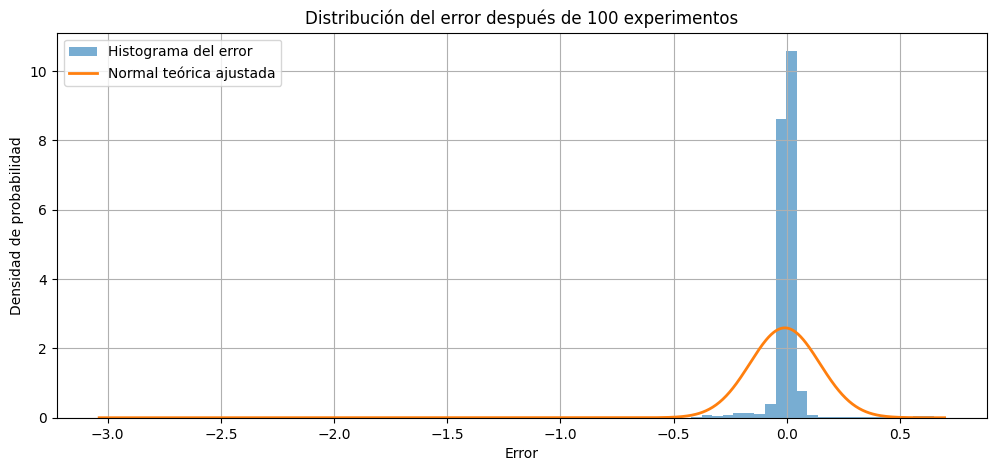

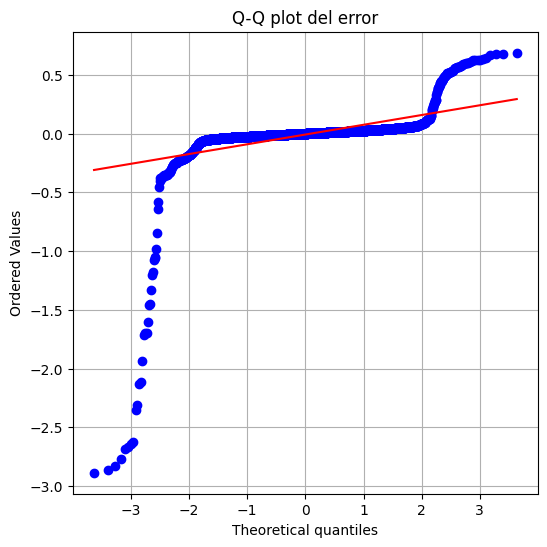

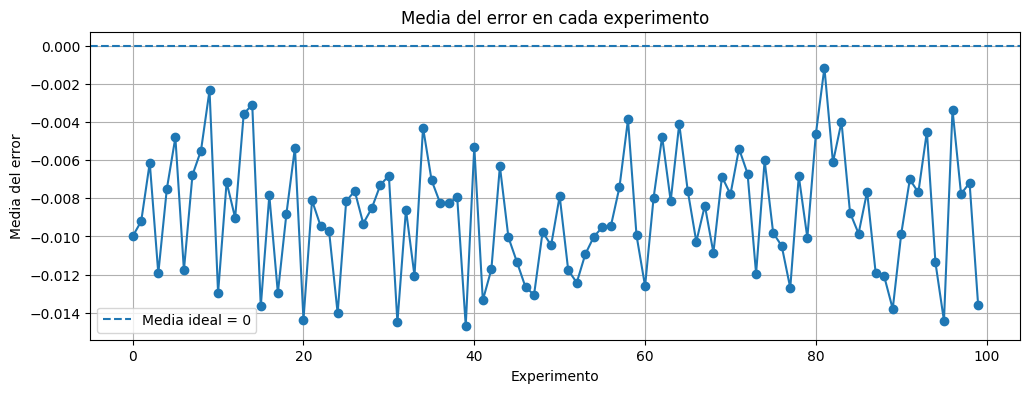

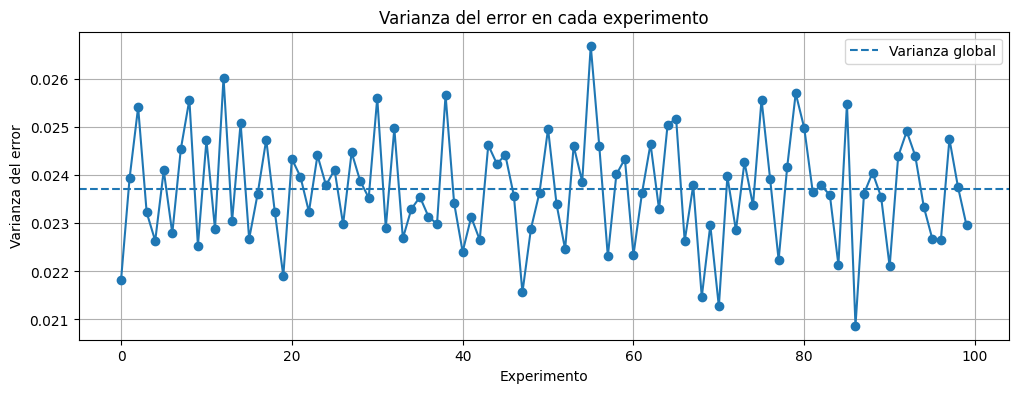

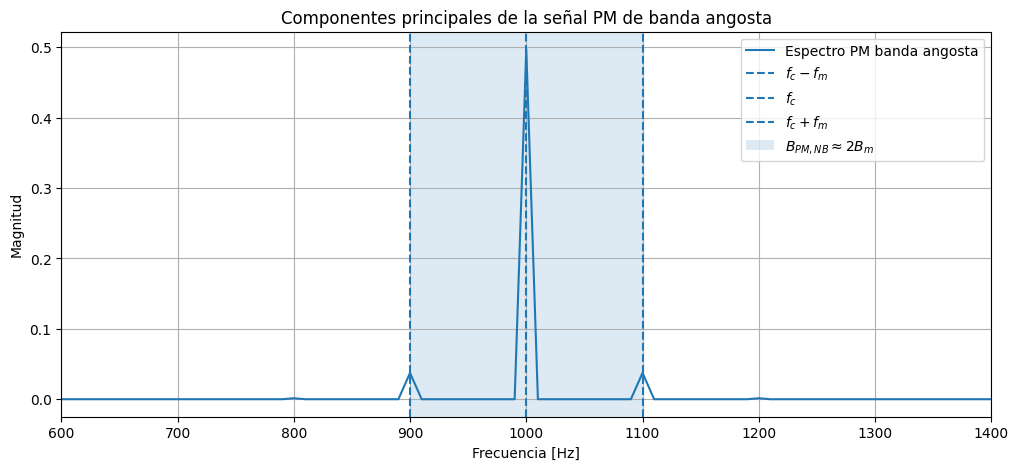

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.stats import norm, probplot, shapiro

# ============================================================
# 1. PARÁMETROS GENERALES
# ============================================================

np.random.seed(10)

Ac = 1.0              # Amplitud de la portadora
fc = 1000             # Frecuencia portadora [Hz]
fm = 100              # Frecuencia moduladora [Hz]
beta = 0.15           # Índice PM de banda angosta, beta << 1

fs = 50000            # Frecuencia de muestreo [Hz]
T = 0.1               # Duración [s]
t = np.arange(0, T, 1/fs)
N = len(t)

SNR_dB = 30           # Relación señal a ruido [dB]
num_experimentos = 100

# ============================================================
# 2. SEÑAL MODULADORA NORMALIZADA
# ============================================================

m_n = np.cos(2*np.pi*fm*t)

# Verificación de normalización
m_n = m_n / np.max(np.abs(m_n))

# Ancho de banda del mensaje
Bm = fm

# Ancho de banda aproximado de PM banda angosta
B_PM_NB = 2 * Bm

print("===== CONDICIONES PM DE BANDA ANGOSTA =====")
print(f"beta = {beta}")
print(f"Condición beta << 1: {'Cumple' if beta < 0.3 else 'No cumple'}")
print(f"fc = {fc} Hz")
print(f"Bm = {Bm} Hz")
print(f"Condición fc >> Bm: {'Cumple' if fc > 5*Bm else 'No cumple'}")
print(f"Ancho de banda PM banda angosta ≈ 2Bm = {B_PM_NB} Hz")

# ============================================================
# 3. SEÑAL PM DE BANDA ANGOSTA
# ============================================================

s_pm = Ac * np.cos(2*np.pi*fc*t + beta*m_n)

# Potencia promedio de la señal PM
Ps = np.mean(s_pm**2)

# Conversión de SNR dB a lineal
SNR_lineal = 10**(SNR_dB/10)

# Potencia y varianza del ruido
Pn = Ps / SNR_lineal
sigma_n = np.sqrt(Pn)

print("\n===== PARÁMETROS DE RUIDO AWGN =====")
print(f"SNR = {SNR_dB} dB")
print(f"SNR lineal = {SNR_lineal:.2f}")
print(f"Potencia de señal Ps = {Ps:.6f}")
print(f"Potencia de ruido Pn = {Pn:.8f}")
print(f"Desviación estándar del ruido sigma_n = {sigma_n:.8f}")

# ============================================================
# 4. FILTRO PASA BAJAS PARA DEMODULACIÓN
# ============================================================

def filtro_pasa_bajas(x, fs, fcorte, orden=5):
    """
    Filtro pasa bajas Butterworth.
    fcorte debe ser mayor que fm pero mucho menor que fc.
    """
    nyq = fs / 2
    Wn = fcorte / nyq
    b, a = butter(orden, Wn, btype='low')
    return filtfilt(b, a, x)

fcorte_lpf = 3 * fm   # Debe dejar pasar el mensaje y rechazar 2fc

# ============================================================
# 5. DEMODULACIÓN COHERENTE PM BANDA ANGOSTA
# ============================================================

def demodular_pm_banda_angosta(r, t, fc, Ac, beta, fs, fcorte_lpf):
    """
    Demodulación coherente para PM de banda angosta.
    Se asume desfase cero en la portadora de recepción.
    
    PM NB:
    s_PM(t) ≈ Ac cos(2πfct) - Ac beta m_n(t) sin(2πfct)
    
    Para recuperar m_n(t), se multiplica por -2 sin(2πfct)
    y luego se aplica filtro pasa bajas.
    """
    
    portadora_rx = -2 * np.sin(2*np.pi*fc*t)  # Desfase cero
    mezclada = r * portadora_rx
    y_lpf = filtro_pasa_bajas(mezclada, fs, fcorte_lpf)
    
    # Normalización
    m_rec = y_lpf / (Ac * beta)
    
    return m_rec, mezclada, y_lpf

# ============================================================
# 6. EXPERIMENTO MONTE CARLO: 100 REPETICIONES
# ============================================================

errores = []
recuperadas = []

for i in range(num_experimentos):
    
    # Ruido AWGN diferente en cada experimento
    ruido = sigma_n * np.random.randn(N)
    
    # Señal recibida
    r = s_pm + ruido
    
    # Demodulación coherente
    m_rec, mezclada, y_lpf = demodular_pm_banda_angosta(
        r, t, fc, Ac, beta, fs, fcorte_lpf
    )
    
    # Error entre señal recuperada y señal original
    error = m_rec - m_n
    
    errores.append(error)
    recuperadas.append(m_rec)

errores = np.array(errores)
recuperadas = np.array(recuperadas)

# Vector con todos los errores de todos los experimentos
error_total = errores.flatten()

# ============================================================
# 7. MEDIA Y VARIANZA DEL ERROR
# ============================================================

media_error = np.mean(error_total)
varianza_error = np.var(error_total, ddof=1)
std_error = np.sqrt(varianza_error)

print("\n===== ESTADÍSTICAS DEL ERROR =====")
print(f"Número de experimentos = {num_experimentos}")
print(f"Número de muestras por experimento = {N}")
print(f"Número total de muestras de error = {len(error_total)}")
print(f"Media del error = {media_error:.8e}")
print(f"Varianza del error = {varianza_error:.8e}")
print(f"Desviación estándar del error = {std_error:.8e}")

# ============================================================
# 8. PRUEBA SIMPLE DE NORMALIDAD
# ============================================================
# Shapiro-Wilk no es ideal para muchísimas muestras.
# Por eso se toma una submuestra.

submuestra = np.random.choice(error_total, size=5000, replace=False)
stat, p_value = shapiro(submuestra)

print("\n===== PRUEBA DE NORMALIDAD SHAPIRO-WILK =====")
print(f"Estadístico = {stat:.6f}")
print(f"p-value = {p_value:.6f}")

if p_value > 0.05:
    print("Resultado: No se rechaza la hipótesis de normalidad.")
    print("El error puede considerarse aproximadamente gaussiano.")
else:
    print("Resultado: Se rechaza la hipótesis de normalidad.")
    print("El error no se comporta perfectamente como gaussiano.")

# ============================================================
# 9. GRÁFICAS EN EL TIEMPO
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(t, m_n, label="Mensaje original $m_n(t)$")
plt.plot(t, recuperadas[0], "--", label="Mensaje recuperado, experimento 1")
plt.title("Demodulación coherente PM banda angosta con AWGN, SNR = 30 dB")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.xlim(0, 0.04)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t, errores[0])
plt.title("Error de recuperación en el experimento 1")
plt.xlabel("Tiempo [s]")
plt.ylabel("Error")
plt.grid(True)
plt.xlim(0, 0.04)
plt.show()

# ============================================================
# 10. HISTOGRAMA DEL ERROR Y NORMAL TEÓRICA
# ============================================================

plt.figure(figsize=(12, 5))

conteo, bins, _ = plt.hist(
    error_total,
    bins=80,
    density=True,
    alpha=0.6,
    label="Histograma del error"
)

x_pdf = np.linspace(np.min(error_total), np.max(error_total), 1000)
pdf_normal = norm.pdf(x_pdf, media_error, std_error)

plt.plot(x_pdf, pdf_normal, linewidth=2, label="Normal teórica ajustada")

plt.title("Distribución del error después de 100 experimentos")
plt.xlabel("Error")
plt.ylabel("Densidad de probabilidad")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# 11. Q-Q PLOT PARA VERIFICAR GAUSSIANIDAD
# ============================================================

plt.figure(figsize=(6, 6))
probplot(submuestra, dist="norm", plot=plt)
plt.title("Q-Q plot del error")
plt.grid(True)
plt.show()

# ============================================================
# 12. MEDIA Y VARIANZA POR EXPERIMENTO
# ============================================================

medias_por_exp = np.mean(errores, axis=1)
varianzas_por_exp = np.var(errores, axis=1, ddof=1)

plt.figure(figsize=(12, 4))
plt.plot(medias_por_exp, marker="o")
plt.axhline(0, linestyle="--", label="Media ideal = 0")
plt.title("Media del error en cada experimento")
plt.xlabel("Experimento")
plt.ylabel("Media del error")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(varianzas_por_exp, marker="o")
plt.axhline(varianza_error, linestyle="--", label="Varianza global")
plt.title("Varianza del error en cada experimento")
plt.xlabel("Experimento")
plt.ylabel("Varianza del error")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# 13. ESPECTRO DE LA SEÑAL PM CON COMPONENTES PRINCIPALES
# ============================================================

def calcular_espectro(x, fs):
    N = len(x)
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))
    mag = np.abs(X) / N
    return f, mag

f, S_mag = calcular_espectro(s_pm, fs)

plt.figure(figsize=(12, 5))
plt.plot(f, S_mag, label="Espectro PM banda angosta")

plt.axvline(fc-fm, linestyle="--", label="$f_c-f_m$")
plt.axvline(fc, linestyle="--", label="$f_c$")
plt.axvline(fc+fm, linestyle="--", label="$f_c+f_m$")

plt.axvspan(fc-Bm, fc+Bm, alpha=0.15, label="$B_{PM,NB}\\approx 2B_m$")

plt.title("Componentes principales de la señal PM de banda angosta")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid(True)
plt.legend()
plt.xlim(fc - 4*fm, fc + 4*fm)
plt.show()

## Experimento con diferentes valores de SNR en pasos de 3 dB

Se desea repetir el experimento anterior para diferentes valores de relación señal a ruido, SNR, desde:

$$
0\,\text{dB}
$$

hasta:

$$
30\,\text{dB}
$$

usando pasos de:

$$
3\,\text{dB}
$$

Esto significa que los valores de SNR usados serán:

$$
SNR_{dB}=\{0,3,6,9,12,15,18,21,24,27,30\}
$$

La expresión “pasos de 3 dB” significa que entre un valor de SNR y el siguiente se aumenta la relación señal a ruido en \(3\,\text{dB}\). Matemáticamente:

$$
SNR_{dB,k}=0+3k
$$

con:

$$
k=0,1,2,\dots,10
$$

Por ejemplo:

$$
SNR_{dB,0}=0\,\text{dB}
$$

$$
SNR_{dB,1}=3\,\text{dB}
$$

$$
SNR_{dB,2}=6\,\text{dB}
$$

y así sucesivamente hasta:

$$
SNR_{dB,10}=30\,\text{dB}
$$

---

## Conversión de SNR en dB a escala lineal

La relación señal a ruido en decibeles se define como:

$$
SNR_{dB}=10\log_{10}\left(\frac{P_s}{P_n}\right)
$$

donde:

- \(P_s\) es la potencia de la señal.
- \(P_n\) es la potencia del ruido.

Para pasar de decibeles a escala lineal:

$$
SNR=10^{SNR_{dB}/10}
$$

Entonces, para cada valor de \(SNR_{dB}\), la potencia de ruido se calcula como:

$$
P_n=\frac{P_s}{SNR}
$$

Sustituyendo:

$$
P_n=\frac{P_s}{10^{SNR_{dB}/10}}
$$

Como el ruido agregado es gaussiano blanco aditivo, AWGN, se modela como:

$$
n(t)\sim \mathcal{N}(0,\sigma_n^2)
$$

y su varianza es igual a la potencia de ruido:

$$
\sigma_n^2=P_n
$$

Por tanto:

$$
\sigma_n^2=\frac{P_s}{10^{SNR_{dB}/10}}
$$

---

## Interpretación de los pasos de 3 dB

Cada vez que el SNR aumenta \(3\,\text{dB}\), la relación señal a ruido en escala lineal aumenta aproximadamente al doble.

Esto se debe a que:

$$
10^{3/10}\approx 1.995 \approx 2
$$

Por eso, pasar de \(0\,\text{dB}\) a \(3\,\text{dB}\) significa que la relación señal a ruido casi se duplica.

Ejemplos:

Para:

$$
SNR_{dB}=0\,\text{dB}
$$

se tiene:

$$
SNR=10^{0/10}=1
$$

Entonces:

$$
P_n=P_s
$$

El ruido tiene una potencia similar a la señal.

Para:

$$
SNR_{dB}=3\,\text{dB}
$$

se tiene:

$$
SNR=10^{3/10}\approx 2
$$

Entonces:

$$
P_n\approx \frac{P_s}{2}
$$

El ruido tiene aproximadamente la mitad de la potencia de la señal.

Para:

$$
SNR_{dB}=30\,\text{dB}
$$

se tiene:

$$
SNR=10^{30/10}=1000
$$

Entonces:

$$
P_n=\frac{P_s}{1000}
$$

El ruido es mucho menor que la señal.

---

## Aplicación al experimento PM de banda angosta

La señal PM de banda angosta es:

$$
s_{PM}(t)=A_c\cos\left(2\pi f_c t+\beta m_n(t)\right)
$$

Para cumplir la condición de banda angosta se debe verificar:

$$
\beta \ll 1
$$

También debe cumplirse:

$$
|m_n(t)|\leq 1
$$

y:

$$
f_c \gg B_m
$$

donde \(B_m\) es el ancho de banda del mensaje.

El índice de modulación de fase \(\beta\) no cambia con el SNR. El SNR solo cambia la potencia del ruido agregado. Por tanto, para todos los valores:

$$
SNR_{dB}=0,3,6,\dots,30
$$

se mantiene el mismo índice:

$$
\beta=\text{constante}
$$

por ejemplo:

$$
\beta=0.15
$$

Como:

$$
0.15 \ll 1
$$

la señal sigue cumpliendo la condición de PM de banda angosta.

---

## Señal recibida para cada SNR

Para cada valor de SNR, la señal recibida será:

$$
r_i(t)=s_{PM}(t)+n_i(t)
$$

donde:

$$
n_i(t)\sim \mathcal{N}(0,\sigma_{n,i}^2)
$$

y:

$$
\sigma_{n,i}^2=\frac{P_s}{10^{SNR_{dB,i}/10}}
$$

Esto significa que para SNR bajos, como \(0\,\text{dB}\), el ruido será fuerte. Para SNR altos, como \(30\,\text{dB}\), el ruido será débil.

---

## Error después de la demodulación

Después de aplicar demodulación coherente con desfase cero, se obtiene una señal recuperada:

$$
\hat{m}_{n,i}(t)
$$

El error se define como:

$$
e_i(t)=\hat{m}_{n,i}(t)-m_n(t)
$$

Para cada valor de SNR se calcula:

$$
\mu_e=
\frac{1}{N}
\sum_{n=0}^{N-1}e_i[n]
$$

y:

$$
\sigma_e^2=
\frac{1}{N-1}
\sum_{n=0}^{N-1}
\left(e_i[n]-\mu_e\right)^2
$$

Conceptualmente, al aumentar el SNR, la potencia del ruido disminuye. Por tanto, se espera que la varianza del error también disminuya.

En resumen:

$$
SNR_{dB}\uparrow
\quad \Rightarrow \quad
P_n\downarrow
\quad \Rightarrow \quad
\sigma_e^2\downarrow
$$

Esto significa que mientras mayor sea la relación señal a ruido, mejor será la recuperación de la señal moduladora.

## Análisis del error al variar la potencia del ruido

En el experimento se tiene una señal PM de banda angosta:

$$
s_{PM}(t)=A_c\cos\left(2\pi f_c t+\beta m_n(t)\right)
$$

donde se cumplen las condiciones de banda angosta:

$$
|m_n(t)|\leq 1
$$

$$
\beta \ll 1
$$

$$
f_c \gg B_m
$$

Para banda angosta, la señal se aproxima como:

$$
s_{PM}(t)\approx A_c\cos(2\pi f_c t)-A_c\beta m_n(t)\sin(2\pi f_c t)
$$

El primer término es la portadora dominante y el segundo contiene la información del mensaje en cuadratura.

---

## Señal con ruido AWGN

Al agregar ruido gaussiano blanco aditivo, la señal recibida es:

$$
r(t)=s_{PM}(t)+n(t)
$$

donde:

$$
n(t)\sim \mathcal{N}(0,\sigma_n^2)
$$

La potencia del ruido depende de la relación señal a ruido:

$$
SNR=\frac{P_s}{P_n}
$$

En decibeles:

$$
SNR_{dB}=10\log_{10}\left(\frac{P_s}{P_n}\right)
$$

Despejando la potencia de ruido:

$$
P_n=\frac{P_s}{10^{SNR_{dB}/10}}
$$

Como el ruido AWGN tiene media cero, su varianza es igual a su potencia:

$$
\sigma_n^2=P_n
$$

Por tanto:

$$
\sigma_n^2=\frac{P_s}{10^{SNR_{dB}/10}}
$$

Esto significa que cuando el SNR aumenta, la potencia del ruido disminuye. Cuando el SNR disminuye, la potencia del ruido aumenta.

---

## ¿Qué significa variar el SNR de 0 dB a 30 dB?

Se usan valores:

$$
SNR_{dB}=\{0,3,6,9,12,15,18,21,24,27,30\}
$$

Los pasos de \(3\,\text{dB}\) significan que cada nuevo valor aumenta aproximadamente al doble la relación señal a ruido, porque:

$$
10^{3/10}\approx 2
$$

Por ejemplo:

Para:

$$
SNR_{dB}=0\,\text{dB}
$$

se tiene:

$$
SNR=1
$$

por tanto:

$$
P_n=P_s
$$

El ruido tiene una potencia similar a la señal.

Para:

$$
SNR_{dB}=30\,\text{dB}
$$

se tiene:

$$
SNR=1000
$$

por tanto:

$$
P_n=\frac{P_s}{1000}
$$

El ruido es mucho menor que la señal.

---

## Demodulación coherente con desfase cero

Para PM de banda angosta, la información está en la componente en cuadratura. Por eso se multiplica la señal recibida por:

$$
c_L(t)=-2\sin(2\pi f_c t)
$$

Entonces:

$$
y(t)=r(t)c_L(t)
$$

Sustituyendo:

$$
y(t)=
\left[
A_c\cos(2\pi f_c t)
-
A_c\beta m_n(t)\sin(2\pi f_c t)
+
n(t)
\right]
[-2\sin(2\pi f_c t)]
$$

Después de multiplicar y aplicar un filtro pasa bajas, se obtiene:

$$
y_{LPF}(t)=A_c\beta m_n(t)+\tilde{n}(t)
$$

donde \(\tilde{n}(t)\) es el ruido trasladado a banda base.

La señal recuperada se obtiene dividiendo entre \(A_c\beta\):

$$
\hat{m}_n(t)=\frac{y_{LPF}(t)}{A_c\beta}
$$

Por tanto:

$$
\hat{m}_n(t)=m_n(t)+\frac{\tilde{n}(t)}{A_c\beta}
$$

---

## Definición del error

El error de recuperación se define como:

$$
e(t)=\hat{m}_n(t)-m_n(t)
$$

Sustituyendo:

$$
e(t)=\frac{\tilde{n}(t)}{A_c\beta}
$$

Esto muestra que, si el desfase de la portadora es cero, el error se debe principalmente al ruido.

Como en el documento experimental, cuando el desfase es \(\phi=0\), no aparece atenuación por fase en la demodulación coherente; la degradación viene del ruido agregado por el canal. :contentReference[oaicite:0]{index=0}

---

## Media del error

La media del error se calcula como:

$$
\mu_e=\frac{1}{N}\sum_{n=0}^{N-1}e[n]
$$

Como el ruido AWGN tiene media cero:

$$
\mathbb{E}\{n(t)\}=0
$$

entonces se espera que:

$$
\mu_e\approx 0
$$

Esto significa que el error no debería tener un desplazamiento constante o sesgo.

---

## Varianza del error

La varianza del error se calcula como:

$$
\sigma_e^2=
\frac{1}{N-1}
\sum_{n=0}^{N-1}
\left(e[n]-\mu_e\right)^2
$$

La varianza mide qué tan disperso está el error alrededor de su media.

Cuando aumenta la potencia del ruido:

$$
P_n \uparrow
$$

también aumenta la varianza del error:

$$
\sigma_e^2 \uparrow
$$

Cuando aumenta el SNR:

$$
SNR_{dB}\uparrow
$$

la potencia del ruido disminuye:

$$
P_n\downarrow
$$

y por tanto la varianza del error también disminuye:

$$
\sigma_e^2\downarrow
$$

---

## Distorsión por valor del error y estructura del error

El análisis se puede dividir en dos partes.

### 1. Valor estadístico del error

Aquí se analiza el tamaño del error mediante:

$$
\mu_e
$$

$$
\sigma_e^2
$$

$$
MSE=\frac{1}{N}\sum_{n=0}^{N-1}e^2[n]
$$

Si el SNR es bajo, el ruido es grande y se espera:

$$
\sigma_e^2 \text{ alta}
$$

$$
MSE \text{ alto}
$$

Si el SNR es alto, el ruido es pequeño y se espera:

$$
\sigma_e^2 \text{ baja}
$$

$$
MSE \text{ bajo}
$$

---

### 2. Estructura temporal del error

Aquí se observa la forma de:

$$
e(t)
$$

Si el error proviene principalmente de AWGN, debe verse como una señal aleatoria sin forma determinística clara.

Para SNR bajo, por ejemplo \(0\,\text{dB}\), el error tendrá mayor amplitud y la señal recuperada se verá más distorsionada.

Para SNR alto, por ejemplo \(30\,\text{dB}\), el error tendrá menor amplitud y la señal recuperada será muy parecida a la señal original.

---

## ¿El error es gaussiano?

Como el ruido agregado es gaussiano:

$$
n(t)\sim \mathcal{N}(0,\sigma_n^2)
$$

y la demodulación coherente de PM de banda angosta usa operaciones aproximadamente lineales, el error también debería comportarse aproximadamente como una variable gaussiana:

$$
e[n]\sim \mathcal{N}(\mu_e,\sigma_e^2)
$$

con:

$$
\mu_e\approx 0
$$

Para verificarlo se pueden usar:

- histograma del error,
- curva normal ajustada,
- gráfico Q-Q,
- prueba de normalidad.

Si el histograma tiene forma de campana y el Q-Q plot se aproxima a una línea recta, entonces el error puede considerarse aproximadamente gaussiano.

---

## Interpretación final

Al variar el SNR entre \(0\,\text{dB}\) y \(30\,\text{dB}\), se está variando directamente la potencia del ruido.

Para SNR bajo:

$$
P_n \text{ grande}
$$

$$
\sigma_e^2 \text{ grande}
$$

$$
MSE \text{ grande}
$$

La señal recuperada presenta mayor distorsión.

Para SNR alto:

$$
P_n \text{ pequeña}
$$

$$
\sigma_e^2 \text{ pequeña}
$$

$$
MSE \text{ pequeño}
$$

La señal recuperada se parece más a la señal original.

Por tanto, el experimento permite observar dos cosas: cómo cambia el valor estadístico del error y cómo cambia visualmente la estructura temporal del error al aumentar o disminuir la potencia del ruido.

===== CONDICIONES PM DE BANDA ANGOSTA =====
beta = 0.15
Condición beta << 1: Cumple
max |m_n(t)| = 1.00
Condición |m_n(t)| <= 1: Cumple
fc = 1000 Hz
Bm = 100 Hz
Condición fc >> Bm: Cumple
Ancho de banda PM banda angosta ≈ 2Bm = 200 Hz

===== RESULTADOS PROMEDIADOS POR SNR =====
SNR[dB] | beta | Pn | media_error | var_error | std_error | MSE | Distorsión[%]
      0 | 0.15 | 5.000e-01 | -5.509e-03 | 4.741e-01 | 6.849e-01 | 4.855e-01 | 98.044
      3 | 0.15 | 2.506e-01 | -4.990e-04 | 2.371e-01 | 4.848e-01 | 2.408e-01 | 69.102
      6 | 0.15 | 1.256e-01 | +3.376e-03 | 1.167e-01 | 3.400e-01 | 1.197e-01 | 48.709
      9 | 0.15 | 6.295e-02 | -8.370e-03 | 5.928e-02 | 2.423e-01 | 6.092e-02 | 34.754
     12 | 0.15 | 3.155e-02 | +4.482e-03 | 2.935e-02 | 1.704e-01 | 3.034e-02 | 24.509
     15 | 0.15 | 1.581e-02 | -2.283e-03 | 1.526e-02 | 1.227e-01 | 1.561e-02 | 17.544
     18 | 0.15 | 7.924e-03 | -1.703e-03 | 7.342e-03 | 8.522e-02 | 7.523e-03 | 12.202
     21 | 0.15 | 3.972e-03 | +1.268e-04 | 3.91

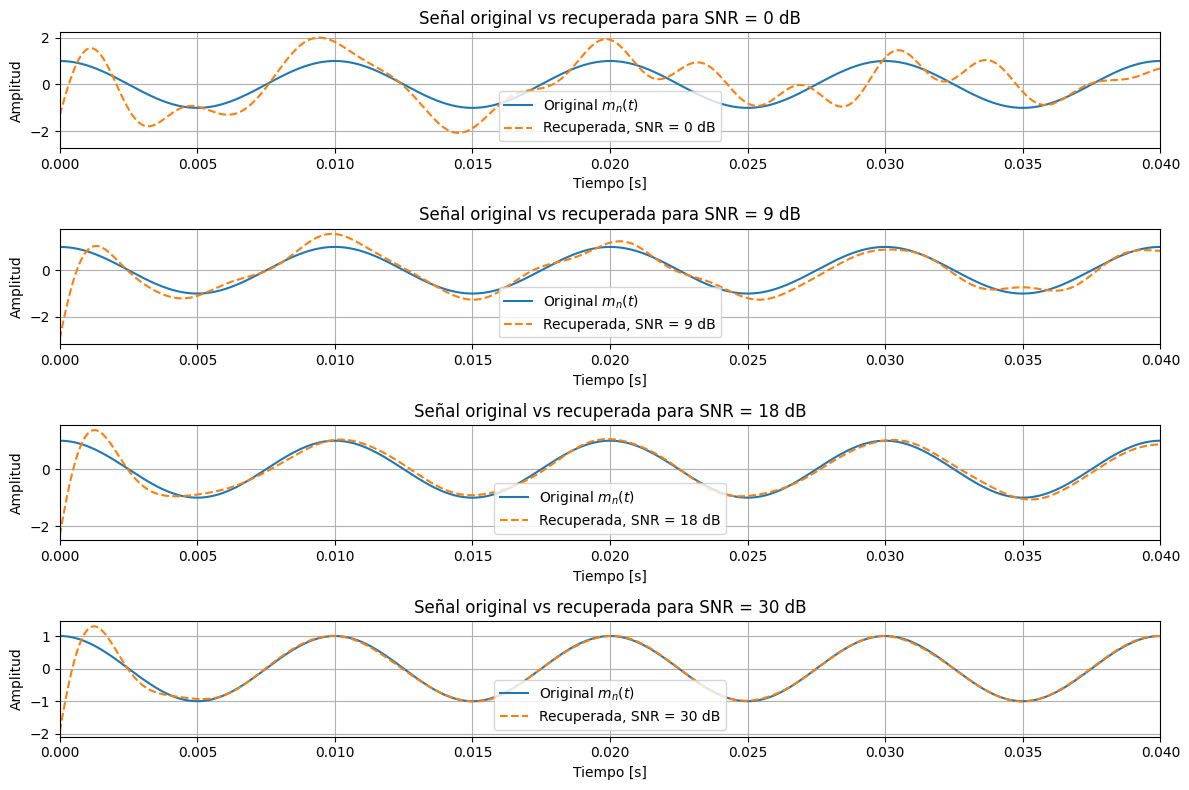

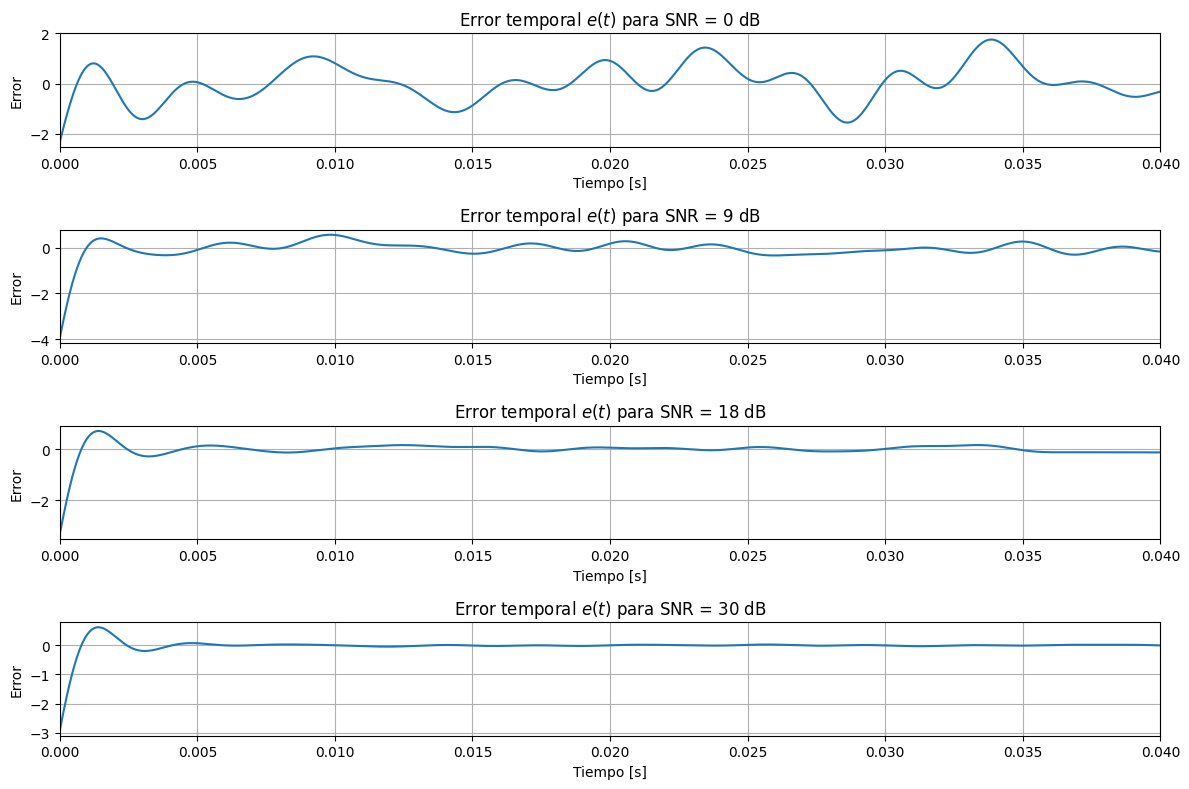

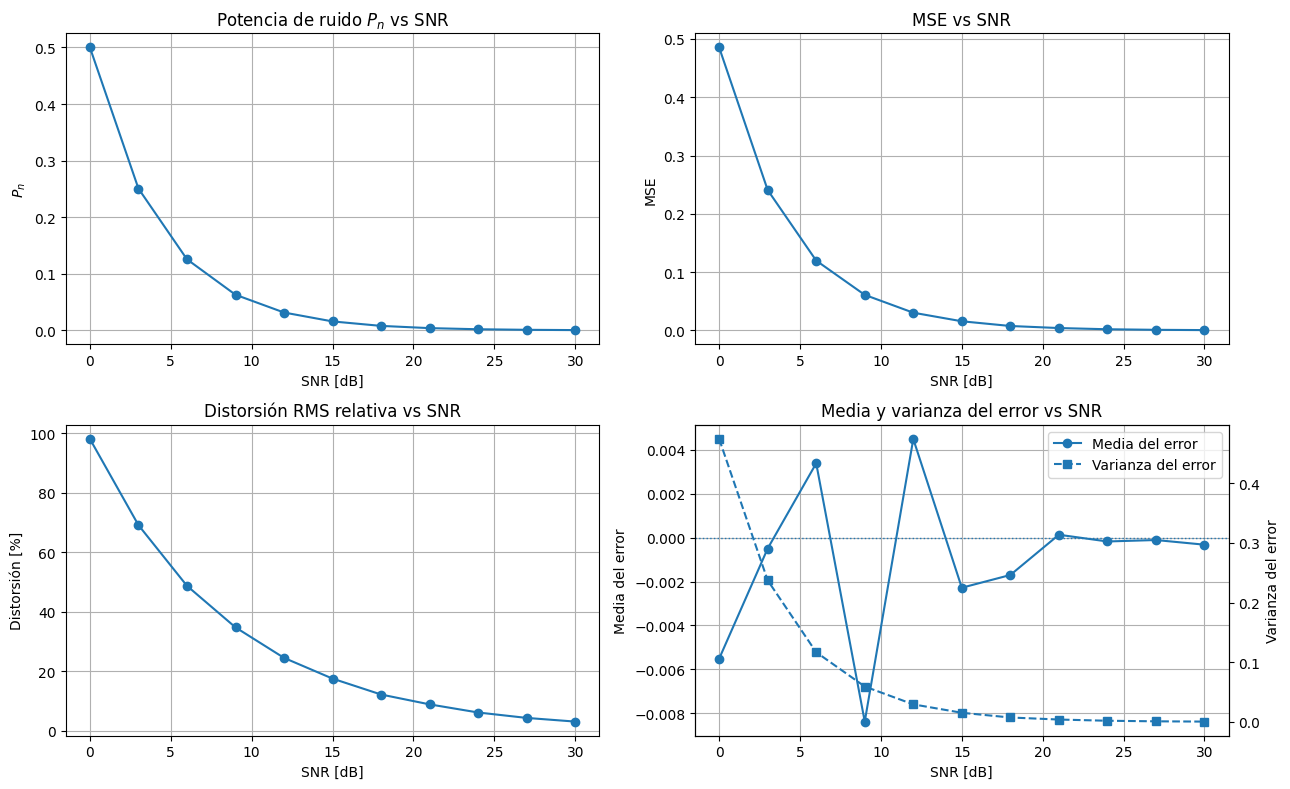

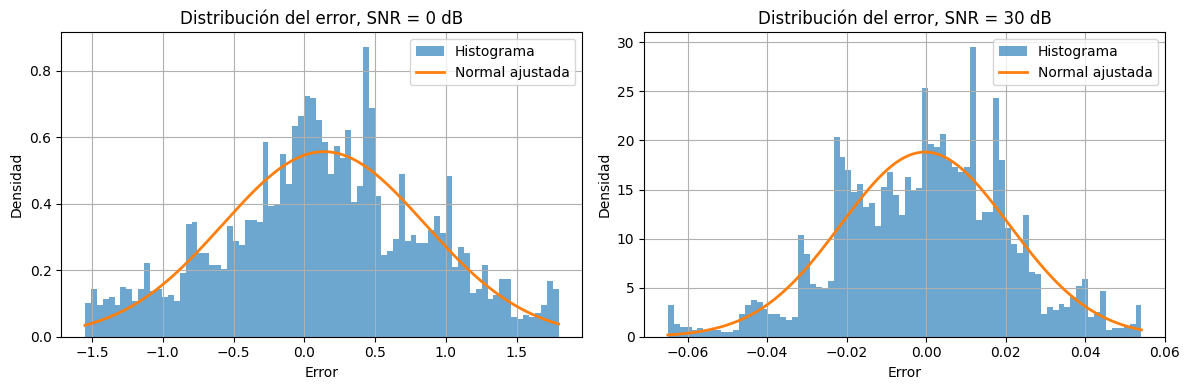

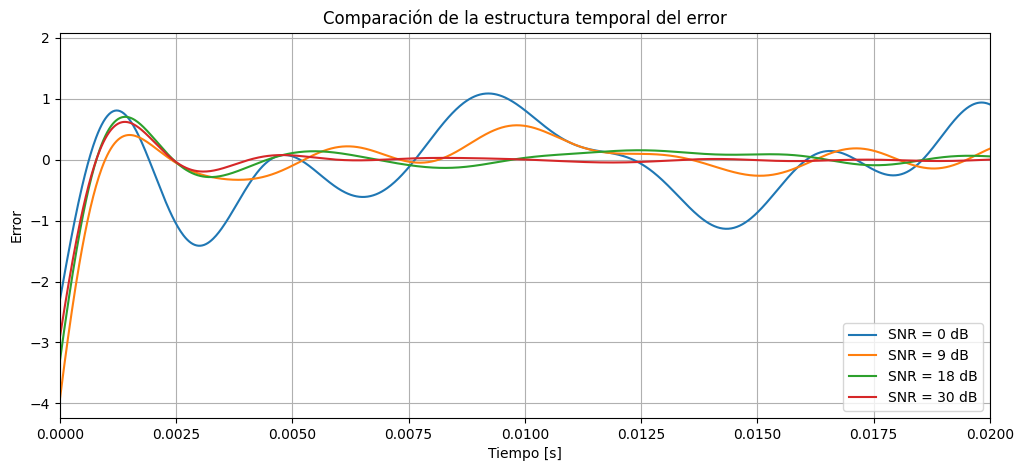

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.stats import norm

# ============================================================
# 1. PARÁMETROS PM DE BANDA ANGOSTA
# ============================================================

np.random.seed(7)

Ac = 1.0
fc = 1000          # Hz
fm = 100           # Hz
beta = 0.15        # beta << 1

fs = 50000         # Hz
T = 0.1            # s
t = np.arange(0, T, 1/fs)
N = len(t)

SNR_dB_values = np.arange(0, 31, 3)

# Número de realizaciones Monte Carlo por cada SNR
num_realizaciones = 100

# ============================================================
# 2. SEÑAL MODULADORA Y PM
# ============================================================

m_n = np.cos(2*np.pi*fm*t)
m_n = m_n / np.max(np.abs(m_n))   # |m_n(t)| <= 1

s_pm = Ac * np.cos(2*np.pi*fc*t + beta*m_n)

Ps = np.mean(s_pm**2)

Bm = fm
B_PM_NB = 2 * Bm

print("===== CONDICIONES PM DE BANDA ANGOSTA =====")
print(f"beta = {beta}")
print(f"Condición beta << 1: {'Cumple' if beta < 0.3 else 'No cumple'}")
print(f"max |m_n(t)| = {np.max(np.abs(m_n)):.2f}")
print(f"Condición |m_n(t)| <= 1: {'Cumple' if np.max(np.abs(m_n)) <= 1 else 'No cumple'}")
print(f"fc = {fc} Hz")
print(f"Bm = {Bm} Hz")
print(f"Condición fc >> Bm: {'Cumple' if fc > 5*Bm else 'No cumple'}")
print(f"Ancho de banda PM banda angosta ≈ 2Bm = {B_PM_NB} Hz")

# ============================================================
# 3. FILTRO PASA BAJAS
# ============================================================

def filtro_pasa_bajas(x, fs, fcorte, orden=5):
    nyq = fs / 2
    Wn = fcorte / nyq
    b, a = butter(orden, Wn, btype="low")
    return filtfilt(b, a, x)

fcorte_lpf = 3 * fm

# ============================================================
# 4. DEMODULACIÓN COHERENTE PM BANDA ANGOSTA
# ============================================================

def demodular_pm_nb(r, t, fc, Ac, beta, fs, fcorte_lpf):
    portadora_rx = -2 * np.sin(2*np.pi*fc*t)
    mezclada = r * portadora_rx
    y_lpf = filtro_pasa_bajas(mezclada, fs, fcorte_lpf)
    m_rec = y_lpf / (Ac * beta)
    return m_rec

# ============================================================
# 5. ZONA ÚTIL PARA EVITAR TRANSITORIOS DEL FILTRO
# ============================================================

inicio = int(0.01 * fs)
fin = int(0.09 * fs)

m_util = m_n[inicio:fin]
rms_mensaje = np.sqrt(np.mean(m_util**2))

# ============================================================
# 6. MONTE CARLO PARA CADA SNR
# ============================================================

resultados = []
recuperadas_demo = {}
errores_demo = {}

for SNR_dB in SNR_dB_values:
    
    SNR_lineal = 10**(SNR_dB/10)
    Pn = Ps / SNR_lineal
    sigma_n = np.sqrt(Pn)
    
    medias = []
    varianzas = []
    stds = []
    mses = []
    distorsiones = []
    
    for r_idx in range(num_realizaciones):
        
        ruido = sigma_n * np.random.randn(N)
        r = s_pm + ruido
        
        m_rec = demodular_pm_nb(r, t, fc, Ac, beta, fs, fcorte_lpf)
        error = m_rec - m_n
        
        # Quitar transitorios
        error_util = error[inicio:fin]
        m_rec_util = m_rec[inicio:fin]
        
        media_error = np.mean(error_util)
        var_error = np.var(error_util, ddof=1)
        std_error = np.sqrt(var_error)
        mse = np.mean(error_util**2)
        
        # Curva de distorsión: error RMS relativo al RMS del mensaje
        rms_error = np.sqrt(np.mean(error_util**2))
        distorsion_pct = (rms_error / rms_mensaje) * 100
        
        medias.append(media_error)
        varianzas.append(var_error)
        stds.append(std_error)
        mses.append(mse)
        distorsiones.append(distorsion_pct)
        
        # Guardar una realización para graficar en el tiempo
        if r_idx == 0:
            recuperadas_demo[SNR_dB] = m_rec
            errores_demo[SNR_dB] = error
    
    resultados.append([
        SNR_dB,
        beta,
        Pn,
        np.mean(medias),
        np.mean(varianzas),
        np.mean(stds),
        np.mean(mses),
        np.mean(distorsiones)
    ])

# ============================================================
# 7. TABLA DE RESULTADOS
# ============================================================

print("\n===== RESULTADOS PROMEDIADOS POR SNR =====")
print("SNR[dB] | beta | Pn | media_error | var_error | std_error | MSE | Distorsión[%]")

for fila in resultados:
    print(
        f"{fila[0]:>7.0f} | "
        f"{fila[1]:>4.2f} | "
        f"{fila[2]:.3e} | "
        f"{fila[3]:+.3e} | "
        f"{fila[4]:.3e} | "
        f"{fila[5]:.3e} | "
        f"{fila[6]:.3e} | "
        f"{fila[7]:.3f}"
    )

resultados = np.array(resultados)

SNRs = resultados[:, 0]
Pn_values = resultados[:, 2]
media_values = resultados[:, 3]
var_values = resultados[:, 4]
std_values = resultados[:, 5]
mse_values = resultados[:, 6]
dist_values = resultados[:, 7]

# ============================================================
# 8. SEÑAL ORIGINAL VS RECUPERADA
# ============================================================

SNR_mostrar = [0, 9, 18, 30]

plt.figure(figsize=(12, 8))

for i, snr in enumerate(SNR_mostrar):
    plt.subplot(len(SNR_mostrar), 1, i+1)
    plt.plot(t, m_n, label="Original $m_n(t)$")
    plt.plot(t, recuperadas_demo[snr], "--", label=f"Recuperada, SNR = {snr} dB")
    plt.title(f"Señal original vs recuperada para SNR = {snr} dB")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()
    plt.xlim(0, 0.04)

plt.tight_layout()
plt.show()

# ============================================================
# 9. ERROR TEMPORAL PARA DIFERENTES SNR
# ============================================================

plt.figure(figsize=(12, 8))

for i, snr in enumerate(SNR_mostrar):
    plt.subplot(len(SNR_mostrar), 1, i+1)
    plt.plot(t, errores_demo[snr])
    plt.title(f"Error temporal $e(t)$ para SNR = {snr} dB")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Error")
    plt.grid(True)
    plt.xlim(0, 0.04)

plt.tight_layout()
plt.show()

# ============================================================
# 10. GRÁFICAS COMPACTAS DE MÉTRICAS
# ============================================================

fig, axs = plt.subplots(2, 2, figsize=(13, 8))

# Potencia de ruido
axs[0, 0].plot(SNRs, Pn_values, marker="o")
axs[0, 0].set_title("Potencia de ruido $P_n$ vs SNR")
axs[0, 0].set_xlabel("SNR [dB]")
axs[0, 0].set_ylabel("$P_n$")
axs[0, 0].grid(True)

# MSE
axs[0, 1].plot(SNRs, mse_values, marker="o")
axs[0, 1].set_title("MSE vs SNR")
axs[0, 1].set_xlabel("SNR [dB]")
axs[0, 1].set_ylabel("MSE")
axs[0, 1].grid(True)

# Distorsión
axs[1, 0].plot(SNRs, dist_values, marker="o")
axs[1, 0].set_title("Distorsión RMS relativa vs SNR")
axs[1, 0].set_xlabel("SNR [dB]")
axs[1, 0].set_ylabel("Distorsión [%]")
axs[1, 0].grid(True)

# Media y varianza superpuestas
ax1 = axs[1, 1]
ax2 = ax1.twinx()

line1 = ax1.plot(SNRs, media_values, marker="o", label="Media del error")
line2 = ax2.plot(SNRs, var_values, marker="s", linestyle="--", label="Varianza del error")

ax1.axhline(0, linestyle=":", linewidth=1)

ax1.set_title("Media y varianza del error vs SNR")
ax1.set_xlabel("SNR [dB]")
ax1.set_ylabel("Media del error")
ax2.set_ylabel("Varianza del error")
ax1.grid(True)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.tight_layout()
plt.show()

# ============================================================
# 11. HISTOGRAMAS COMPACTOS DEL ERROR
# ============================================================

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

for ax, snr in zip(axs, [0, 30]):
    
    error = errores_demo[snr][inicio:fin]
    mu = np.mean(error)
    sigma = np.std(error, ddof=1)
    
    x_pdf = np.linspace(np.min(error), np.max(error), 1000)
    pdf = norm.pdf(x_pdf, mu, sigma)
    
    ax.hist(error, bins=80, density=True, alpha=0.65, label="Histograma")
    ax.plot(x_pdf, pdf, linewidth=2, label="Normal ajustada")
    ax.set_title(f"Distribución del error, SNR = {snr} dB")
    ax.set_xlabel("Error")
    ax.set_ylabel("Densidad")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 12. COMPARACIÓN DE ESTRUCTURA TEMPORAL DEL ERROR
# ============================================================

plt.figure(figsize=(12, 5))

for snr in SNR_mostrar:
    plt.plot(t, errores_demo[snr], label=f"SNR = {snr} dB")

plt.title("Comparación de la estructura temporal del error")
plt.xlabel("Tiempo [s]")
plt.ylabel("Error")
plt.grid(True)
plt.legend()
plt.xlim(0, 0.02)
plt.show()

## Comparación de distorsión para dos valores de \(\beta\) en PM

Se desea comparar dos casos de modulación en fase, PM, usando el mismo experimento con ruido AWGN y demodulación coherente:

1. Un caso de **PM de banda angosta**, donde:

$$
\beta \ll 1
$$

2. Un caso donde:

$$
\beta > 1
$$

En el primer caso se cumple la aproximación de banda angosta. En el segundo caso, esa aproximación deja de ser válida. Esto no debe interpretarse como “sobremodulación” en el mismo sentido de AM DSB-LC; en PM, lo que ocurre es que al aumentar \(\beta\), la desviación de fase se vuelve grande y aparecen más componentes espectrales significativas.

---

## Señal PM general

La señal modulada en fase se define como:

$$
s_{PM}(t)=A_c\cos\left(2\pi f_c t+\beta m_n(t)\right)
$$

donde:

- \(A_c\) es la amplitud de la portadora.
- \(f_c\) es la frecuencia de la portadora.
- \(m_n(t)\) es la señal moduladora normalizada.
- \(\beta\) es el índice de modulación de fase.

La señal moduladora debe cumplir:

$$
|m_n(t)|\leq 1
$$

Por tanto, la máxima desviación de fase está controlada directamente por \(\beta\):

$$
|\Delta \phi(t)|_{\max}=\beta
$$

---

## Caso 1: PM de banda angosta

Para PM de banda angosta se cumple:

$$
\beta \ll 1
$$

Entonces:

$$
\beta m_n(t) \ll 1
$$

y se pueden usar las aproximaciones de ángulo pequeño:

$$
\cos(\beta m_n(t))\approx 1
$$

$$
\sin(\beta m_n(t))\approx \beta m_n(t)
$$

Partiendo de:

$$
s_{PM}(t)=A_c\cos\left(2\pi f_c t+\beta m_n(t)\right)
$$

usando:

$$
\cos(a+b)=\cos(a)\cos(b)-\sin(a)\sin(b)
$$

se obtiene:

$$
s_{PM}(t)\approx A_c\cos(2\pi f_c t)
-
A_c\beta m_n(t)\sin(2\pi f_c t)
$$

Esta expresión muestra que la señal tiene una portadora dominante y una componente proporcional al mensaje en cuadratura. En este caso, la demodulación coherente usada en el experimento es válida porque se basa precisamente en esta aproximación.

El ancho de banda aproximado es:

$$
B_{PM,NB}\approx 2B_m
$$

donde \(B_m\) es el ancho de banda del mensaje.

---

## Caso 2: \(\beta>1\)

Cuando:

$$
\beta>1
$$

la desviación de fase ya no es pequeña. Por tanto:

$$
\beta m_n(t) \not\ll 1
$$

y las aproximaciones:

$$
\cos(\beta m_n(t))\approx 1
$$

$$
\sin(\beta m_n(t))\approx \beta m_n(t)
$$

dejan de ser válidas.

En este caso, la señal PM debe considerarse como:

$$
s_{PM}(t)=A_c\cos\left(2\pi f_c t+\beta m_n(t)\right)
$$

sin aproximación de banda angosta.

Conceptualmente, al aumentar \(\beta\), la fase de la portadora varía más fuertemente. Esto genera más componentes espectrales alrededor de la portadora y aumenta el ancho de banda ocupado. Por tanto, la demodulación basada en el modelo de banda angosta ya no recupera correctamente \(m_n(t)\).

---

## Señal recibida con ruido AWGN

Para ambos valores de \(\beta\), la señal se transmite por un canal con ruido gaussiano blanco aditivo:

$$
r(t)=s_{PM}(t)+n(t)
$$

donde:

$$
n(t)\sim \mathcal{N}(0,\sigma_n^2)
$$

La potencia del ruido se define a partir del SNR:

$$
SNR_{dB}=10\log_{10}\left(\frac{P_s}{P_n}\right)
$$

Despejando:

$$
P_n=\frac{P_s}{10^{SNR_{dB}/10}}
$$

Como el ruido es AWGN:

$$
\sigma_n^2=P_n
$$

---

## Demodulación coherente usada en el experimento

Para PM de banda angosta, la demodulación coherente se realiza multiplicando por una portadora local en cuadratura:

$$
c_L(t)=-2\sin(2\pi f_c t)
$$

Entonces:

$$
y(t)=r(t)c_L(t)
$$

Luego se aplica un filtro pasa bajas:

$$
y_{LPF}(t)=LPF\{y(t)\}
$$

y se normaliza:

$$
\hat{m}_n(t)=\frac{y_{LPF}(t)}{A_c\beta}
$$

Para \(\beta \ll 1\), esta recuperación es coherente con el modelo aproximado:

$$
s_{PM}(t)\approx A_c\cos(2\pi f_c t)
-
A_c\beta m_n(t)\sin(2\pi f_c t)
$$

Por eso, si el ruido no es muy alto, se espera una recuperación adecuada.

Para \(\beta>1\), se aplica el mismo procedimiento experimental, pero la aproximación de banda angosta ya no se cumple. Por tanto, aunque se use el mismo demodulador, se espera mayor error y mayor distorsión.

---

## Error de recuperación

Para cada valor de SNR y para cada caso de \(\beta\), se calcula el error:

$$
e(t)=\hat{m}_n(t)-m_n(t)
$$

Si la recuperación es buena, entonces:

$$
e(t)\approx 0
$$

Si la recuperación se degrada, el error aumenta.

---

## Distorsión de la señal recuperada

La distorsión se puede medir usando el error RMS relativo:

$$
D(\%)=
\frac{\mathrm{RMS}(e)}{\mathrm{RMS}(m_n)}
\times 100
$$

donde:

$$
\mathrm{RMS}(e)=
\sqrt{
\frac{1}{N}
\sum_{n=0}^{N-1} e^2[n]
}
$$

y:

$$
\mathrm{RMS}(m_n)=
\sqrt{
\frac{1}{N}
\sum_{n=0}^{N-1} m_n^2[n]
}
$$

Por tanto:

$$
D(\%)=
\frac{
\sqrt{
\frac{1}{N}
\sum_{n=0}^{N-1} e^2[n]
}
}{
\sqrt{
\frac{1}{N}
\sum_{n=0}^{N-1} m_n^2[n]
}
}
\times 100
$$

Esta métrica indica qué tan grande es el error comparado con la magnitud de la señal original.

---

## Comparación esperada

Para el caso:

$$
\beta \ll 1
$$

se espera menor distorsión porque:

- se cumple la condición de banda angosta;
- la aproximación matemática usada por el demodulador es válida;
- la señal recuperada debe parecerse más a \(m_n(t)\).

Para el caso:

$$
\beta>1
$$

se espera mayor distorsión porque:

- la desviación de fase ya no es pequeña;
- aparecen más componentes espectrales;
- el ancho de banda aumenta;
- la aproximación de banda angosta deja de ser válida;
- el demodulador coherente usado ya no representa correctamente el comportamiento real de la señal.

---

## Objetivo de superponer las curvas

Para cada valor de SNR se calcula la distorsión en ambos casos:

$$
D_{\beta \ll 1}(SNR)
$$

y:

$$
D_{\beta>1}(SNR)
$$

Luego se superponen las curvas:

$$
D(\%) \quad \text{vs} \quad SNR_{dB}
$$

El objetivo es observar cómo cambia la distorsión cuando:

1. Se mantiene la condición de PM de banda angosta.
2. Se rompe la condición de PM de banda angosta.

Se espera que, al aumentar el SNR, ambas curvas disminuyan porque hay menos ruido. Sin embargo, la curva para \(\beta>1\) puede quedar por encima de la curva de \(\beta\ll1\), debido a que además del ruido existe error por usar una aproximación de banda angosta que ya no es válida.

===== CONDICIONES DEL EXPERIMENTO =====
max |m_n(t)| = 1.00
fc = 1000 Hz
Bm = 100 Hz
fc >> Bm: Cumple
B_PM_NB ≈ 2Bm = 200 Hz
beta_nb = 0.15 -> cumple banda angosta
beta_wb = 1.5 -> no cumple banda angosta

===== MEDIA Y VARIANZA DE LA DISTORSIÓN VS SNR =====
SNR[dB] | Media D beta<<1 [%] | Var D beta<<1 | Media D beta>1 [%] | Var D beta>1
      0 |              97.6114 |    8.8440e+01 |             27.7601 |   1.8636e+00
      3 |              69.4263 |    5.3314e+01 |             26.8694 |   1.0733e+00
      6 |              49.1273 |    2.8584e+01 |             26.3949 |   5.7098e-01
      9 |              34.8528 |    1.2907e+01 |             26.2079 |   2.9882e-01
     12 |              24.7777 |    6.1281e+00 |             26.0482 |   1.2742e-01
     15 |              17.4647 |    3.0646e+00 |             25.9700 |   6.7892e-02
     18 |              12.4076 |    1.5627e+00 |             25.9644 |   3.2488e-02
     21 |               8.7711 |    8.3191e-01 |             25.9472 | 

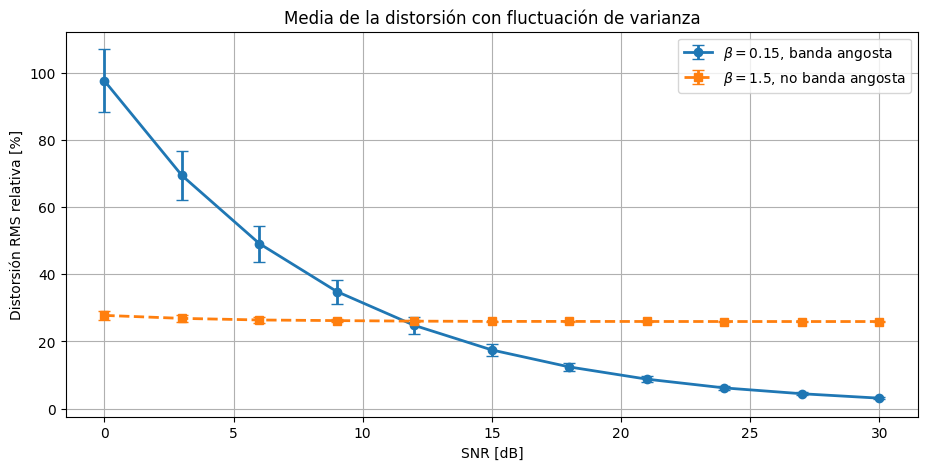

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# ============================================================
# 1. PARÁMETROS GENERALES
# ============================================================

np.random.seed(7)

Ac = 1.0
fc = 1000          # Hz
fm = 100           # Hz

beta_nb = 0.15     # Caso banda angosta: beta << 1
beta_wb = 1.5      # Caso no banda angosta: beta > 1

fs = 50000         # Hz
T = 0.1            # s
t = np.arange(0, T, 1/fs)
N = len(t)

SNR_dB_values = np.arange(0, 31, 3)
num_realizaciones = 300

# ============================================================
# 2. SEÑAL MODULADORA NORMALIZADA
# ============================================================

m_n = np.cos(2*np.pi*fm*t)
m_n = m_n / np.max(np.abs(m_n))

Bm = fm
B_PM_NB = 2 * Bm

print("===== CONDICIONES DEL EXPERIMENTO =====")
print(f"max |m_n(t)| = {np.max(np.abs(m_n)):.2f}")
print(f"fc = {fc} Hz")
print(f"Bm = {Bm} Hz")
print(f"fc >> Bm: {'Cumple' if fc > 5*Bm else 'No cumple'}")
print(f"B_PM_NB ≈ 2Bm = {B_PM_NB} Hz")
print(f"beta_nb = {beta_nb} -> cumple banda angosta")
print(f"beta_wb = {beta_wb} -> no cumple banda angosta")

# ============================================================
# 3. FILTRO PASA BAJAS
# ============================================================

def filtro_pasa_bajas(x, fs, fcorte, orden=5):
    nyq = fs / 2
    Wn = fcorte / nyq
    b, a = butter(orden, Wn, btype="low")
    return filtfilt(b, a, x)

fcorte_lpf = 3 * fm

# ============================================================
# 4. DEMODULACIÓN COHERENTE PM BANDA ANGOSTA
# ============================================================

def demodular_pm_nb(r, beta):
    portadora_rx = -2 * np.sin(2*np.pi*fc*t)
    mezclada = r * portadora_rx
    y_lpf = filtro_pasa_bajas(mezclada, fs, fcorte_lpf)
    m_rec = y_lpf / (Ac * beta)
    return m_rec

# ============================================================
# 5. ZONA ÚTIL PARA EVITAR TRANSITORIOS DEL FILTRO
# ============================================================

inicio = int(0.01 * fs)
fin = int(0.09 * fs)

m_util = m_n[inicio:fin]
rms_m = np.sqrt(np.mean(m_util**2))

# ============================================================
# 6. FUNCIÓN MONTE CARLO
# ============================================================

def calcular_distorsion_media_varianza_vs_snr(beta):

    s_pm = Ac * np.cos(2*np.pi*fc*t + beta*m_n)
    Ps = np.mean(s_pm**2)

    media_dist_snr = []
    var_dist_snr = []
    std_dist_snr = []

    for SNR_dB in SNR_dB_values:

        SNR_lineal = 10**(SNR_dB/10)
        Pn = Ps / SNR_lineal
        sigma_n = np.sqrt(Pn)

        dist_realizaciones = []

        for _ in range(num_realizaciones):

            ruido = sigma_n * np.random.randn(N)
            r = s_pm + ruido

            m_rec = demodular_pm_nb(r, beta)

            error = m_rec - m_n
            error_util = error[inicio:fin]

            rms_error = np.sqrt(np.mean(error_util**2))
            dist_pct = (rms_error / rms_m) * 100

            dist_realizaciones.append(dist_pct)

        dist_realizaciones = np.array(dist_realizaciones)

        media_dist_snr.append(np.mean(dist_realizaciones))
        var_dist_snr.append(np.var(dist_realizaciones, ddof=1))
        std_dist_snr.append(np.std(dist_realizaciones, ddof=1))

    return (
        np.array(media_dist_snr),
        np.array(var_dist_snr),
        np.array(std_dist_snr)
    )

# ============================================================
# 7. CALCULAR PARA LOS DOS CASOS
# ============================================================

media_dist_nb, var_dist_nb, std_dist_nb = calcular_distorsion_media_varianza_vs_snr(beta_nb)
media_dist_wb, var_dist_wb, std_dist_wb = calcular_distorsion_media_varianza_vs_snr(beta_wb)

# ============================================================
# 8. TABLA DE RESULTADOS
# ============================================================

print("\n===== MEDIA Y VARIANZA DE LA DISTORSIÓN VS SNR =====")
print("SNR[dB] | Media D beta<<1 [%] | Var D beta<<1 | Media D beta>1 [%] | Var D beta>1")

for i, snr in enumerate(SNR_dB_values):
    print(
        f"{snr:>7.0f} | "
        f"{media_dist_nb[i]:>20.4f} | "
        f"{var_dist_nb[i]:>13.4e} | "
        f"{media_dist_wb[i]:>19.4f} | "
        f"{var_dist_wb[i]:>12.4e}"
    )

# ============================================================
# 9. GRÁFICA PRINCIPAL
# ============================================================

plt.figure(figsize=(11, 5))

plt.errorbar(
    SNR_dB_values,
    media_dist_nb,
    yerr=std_dist_nb,
    marker="o",
    capsize=4,
    linewidth=2,
    label=rf"$\beta={beta_nb}$, banda angosta"
)

plt.errorbar(
    SNR_dB_values,
    media_dist_wb,
    yerr=std_dist_wb,
    marker="s",
    capsize=4,
    linewidth=2,
    linestyle="--",
    label=rf"$\beta={beta_wb}$, no banda angosta"
)

plt.title("Media de la distorsión con fluctuación de varianza")
plt.xlabel("SNR [dB]")
plt.ylabel("Distorsión RMS relativa [%]")
plt.grid(True)
plt.legend()
plt.show()

## Efecto del desfase \(\phi=\pi/4\) en la demodulación coherente de PM banda angosta

La señal PM se define como:

$$
s_{PM}(t)=A_c\cos\left(2\pi f_c t+\beta m_n(t)\right)
$$

Para PM de banda angosta se cumple:

$$
\beta \ll 1
$$

y la señal puede aproximarse como:

$$
s_{PM}(t)\approx A_c\cos(2\pi f_c t)-A_c\beta m_n(t)\sin(2\pi f_c t)
$$

En el caso ideal, el receptor demodula con una portadora en cuadratura perfectamente sincronizada:

$$
c_L(t)=-2\sin(2\pi f_c t)
$$

Pero ahora se introduce un desfase:

$$
\phi=\frac{\pi}{4}
$$

por lo que la portadora local del receptor queda:

$$
c_L(t)=-2\sin(2\pi f_c t+\phi)
$$

---

## Demodulación con desfase

Si primero se cancela la portadora dominante y se demodula la componente PM, el resultado en banda base queda aproximadamente:

$$
\hat{m}_n(t)
\approx
\cos(\phi)\frac{\sin(\beta m_n(t))}{\beta}
-
\sin(\phi)\frac{\cos(\beta m_n(t))-1}{\beta}
$$

Para banda angosta:

$$
\beta \ll 1
$$

se usan las aproximaciones:

$$
\sin(\beta m_n(t))\approx \beta m_n(t)
$$

y:

$$
\cos(\beta m_n(t))-1\approx -\frac{\beta^2m_n^2(t)}{2}
$$

Sustituyendo:

$$
\hat{m}_n(t)
\approx
m_n(t)\cos(\phi)
+
\frac{\beta}{2}\sin(\phi)m_n^2(t)
$$

---

## Error de recuperación

El error se define como:

$$
e(t)=\hat{m}_n(t)-m_n(t)
$$

Sustituyendo:

$$
e(t)\approx
m_n(t)\cos(\phi)
+
\frac{\beta}{2}\sin(\phi)m_n^2(t)
-
m_n(t)
$$

Agrupando:

$$
e(t)\approx
m_n(t)(\cos(\phi)-1)
+
\frac{\beta}{2}\sin(\phi)m_n^2(t)
$$

Esta expresión muestra que el error tiene dos partes:

1. Una parte proporcional a \(m_n(t)\):

$$
m_n(t)(\cos(\phi)-1)
$$

Esta parte aparece porque el desfase atenúa la señal recuperada.

2. Una parte proporcional a \(m_n^2(t)\):

$$
\frac{\beta}{2}\sin(\phi)m_n^2(t)
$$

Esta parte aparece por el desfase y por usar la señal PM exacta. Como \(m_n^2(t)\) siempre es positiva, introduce un sesgo en la media del error.

---

## Caso específico \(\phi=\pi/4\)

Para:

$$
\phi=\frac{\pi}{4}
$$

se tiene:

$$
\cos\left(\frac{\pi}{4}\right)=0.707
$$

y:

$$
\sin\left(\frac{\pi}{4}\right)=0.707
$$

Entonces la señal recuperada queda aproximadamente:

$$
\hat{m}_n(t)
\approx
0.707m_n(t)
+
\frac{\beta}{2}(0.707)m_n^2(t)
$$

Esto significa que el mensaje recuperado queda atenuado aproximadamente al \(70.7\%\) de su amplitud original, y además aparece una componente adicional proporcional a \(m_n^2(t)\).

---

## Media del error

Si la señal mensaje es:

$$
m_n(t)=\cos(2\pi f_m t)
$$

su media es aproximadamente cero:

$$
\mathbb{E}\{m_n(t)\}=0
$$

pero:

$$
\mathbb{E}\{m_n^2(t)\}=\frac{1}{2}
$$

Por tanto, la media del error queda aproximadamente:

$$
\mu_e
\approx
\frac{\beta}{2}\sin(\phi)\mathbb{E}\{m_n^2(t)\}
$$

Como:

$$
\mathbb{E}\{m_n^2(t)\}=\frac{1}{2}
$$

entonces:

$$
\mu_e
\approx
\frac{\beta}{4}\sin(\phi)
$$

Para:

$$
\beta=0.15
$$

y:

$$
\phi=\frac{\pi}{4}
$$

se obtiene:

$$
\mu_e
\approx
\frac{0.15}{4}(0.707)
$$

$$
\mu_e\approx 0.0265
$$

Por eso en la gráfica la media del error aparece alrededor de:

$$
0.026
$$

Esto es coherente con el modelo.

---

## Varianza del error

La varianza mide qué tanto fluctúa el error alrededor de su media:

$$
\sigma_e^2=
\frac{1}{N-1}
\sum_{n=0}^{N-1}
(e[n]-\mu_e)^2
$$

Cuando el SNR es bajo, el ruido es grande:

$$
SNR \downarrow \Rightarrow P_n \uparrow
$$

por tanto, la varianza del error es alta.

Cuando el SNR aumenta, la potencia del ruido disminuye:

$$
SNR \uparrow \Rightarrow P_n \downarrow
$$

por tanto, la varianza del error disminuye.

Eso explica por qué en la gráfica la curva de varianza baja al aumentar el SNR.

---

## Qué hace el desfase \(\phi=\pi/4\) en las gráficas

El desfase de \(\pi/4\) produce tres efectos principales:

1. **Atenúa la señal recuperada**

La componente útil queda multiplicada por:

$$
\cos(\phi)
$$

Para \(\phi=\pi/4\):

$$
\cos(\phi)=0.707
$$

Entonces la señal recuperada tiene menor amplitud que la original.

2. **Introduce un sesgo en la media del error**

Aparece un término proporcional a:

$$
m_n^2(t)
$$

Como \(m_n^2(t)\) tiene media positiva, la media del error no queda exactamente en cero, sino alrededor de:

$$
\mu_e\approx 0.0265
$$

3. **Aumenta la distorsión residual**

Aunque el SNR sea alto, el error no desaparece completamente porque existe una distorsión determinística causada por el desfase. El ruido baja con el SNR, pero el error por desfase permanece.

---

## Interpretación final

La gráfica es coherente porque:

- La **media del error** queda cercana a un valor positivo pequeño debido al término \(m_n^2(t)\) generado por el desfase.
- La **varianza del error** disminuye al aumentar el SNR porque la potencia del ruido se reduce.
- El desfase \(\phi=\pi/4\) no solo agrega ruido aparente, sino que cambia la recuperación del mensaje: atenúa la señal útil y genera una distorsión residual.

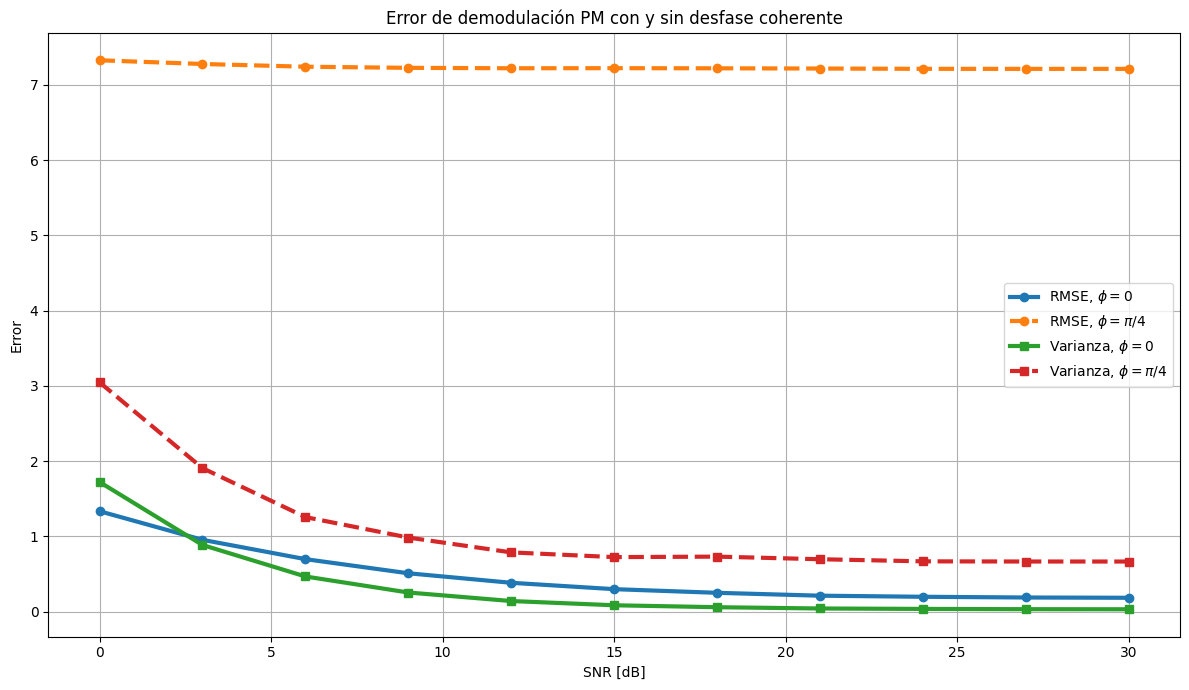

Caso ideal: phi = 0
Caso con desfase: phi = pi/4
100 experimentos por cada SNR


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# ============================================================
# PARÁMETROS
# ============================================================
Ac = 1.0
fc = 1000
fm = 100

# PM de banda angosta
beta = 0.1

fs = 20000
T = 0.05

t = np.arange(0, T, 1/fs)

# Señal moduladora
m_t = np.cos(2*np.pi*fm*t)

# ============================================================
# SEÑAL PM
# ============================================================
s_t = Ac * np.cos(
    2*np.pi*fc*t + beta*m_t
)

# ============================================================
# FILTRO PASA BAJAS
# ============================================================
def lowpass_filter(signal, cutoff, fs, order=6):

    nyq = 0.5 * fs

    normal_cutoff = cutoff / nyq

    b, a = butter(
        order,
        normal_cutoff,
        btype='low'
    )

    return filtfilt(b, a, signal)

# ============================================================
# DEMODULADOR COHERENTE PM
# ============================================================
def coherent_pm_demod(received, beta, phase_offset):

    # Oscilador local con desfase
    lo = np.sin(
        2*np.pi*fc*t + phase_offset
    )

    # Mezcla coherente
    mixed = received * lo

    # Filtro pasa bajas
    recovered = lowpass_filter(
        mixed,
        cutoff=200,
        fs=fs
    )

    # Escalamiento aproximado
    recovered = recovered * (-2/(Ac*beta))

    return recovered

# ============================================================
# SNR
# ============================================================
snr_values_db = np.arange(0, 31, 3)

N_exp = 100

# ============================================================
# DOS CASOS
# ============================================================
phi_ideal = 0
phi_error = np.pi/4

# Resultados
rmse_ideal = []
rmse_phase = []

var_ideal = []
var_phase = []

np.random.seed(7)

# ============================================================
# MONTE CARLO
# ============================================================
for snr_db in snr_values_db:

    rmse_exp_ideal = []
    rmse_exp_phase = []

    var_exp_ideal = []
    var_exp_phase = []

    # --------------------------------------------------------
    # Potencia señal
    # --------------------------------------------------------
    signal_power = np.mean(s_t**2)

    # --------------------------------------------------------
    # Potencia ruido
    # --------------------------------------------------------
    noise_power = signal_power / (
        10**(snr_db/10)
    )

    for _ in range(N_exp):

        # ====================================================
        # Ruido AWGN
        # ====================================================
        noise = np.sqrt(noise_power) * np.random.randn(len(t))

        r_t = s_t + noise

        # ====================================================
        # DEMODULACIÓN IDEAL
        # ====================================================
        rec_ideal = coherent_pm_demod(
            r_t,
            beta,
            phi_ideal
        )

        err_ideal = m_t - rec_ideal

        rmse_exp_ideal.append(
            np.sqrt(np.mean(err_ideal**2))
        )

        var_exp_ideal.append(
            np.var(err_ideal)
        )

        # ====================================================
        # DEMODULACIÓN CON DESFASE
        # ====================================================
        rec_phase = coherent_pm_demod(
            r_t,
            beta,
            phi_error
        )

        err_phase = m_t - rec_phase

        rmse_exp_phase.append(
            np.sqrt(np.mean(err_phase**2))
        )

        var_exp_phase.append(
            np.var(err_phase)
        )

    # ========================================================
    # PROMEDIOS
    # ========================================================
    rmse_ideal.append(
        np.mean(rmse_exp_ideal)
    )

    rmse_phase.append(
        np.mean(rmse_exp_phase)
    )

    var_ideal.append(
        np.mean(var_exp_ideal)
    )

    var_phase.append(
        np.mean(var_exp_phase)
    )

# ============================================================
# ARRAYS
# ============================================================
rmse_ideal = np.array(rmse_ideal)
rmse_phase = np.array(rmse_phase)

var_ideal = np.array(var_ideal)
var_phase = np.array(var_phase)

# ============================================================
# GRÁFICA
# ============================================================
plt.figure(figsize=(12,7))

# ------------------------------------------------------------
# RMSE
# ------------------------------------------------------------
plt.plot(
    snr_values_db,
    rmse_ideal,
    marker='o',
    linewidth=3,
    label=r'RMSE, $\phi = 0$'
)

plt.plot(
    snr_values_db,
    rmse_phase,
    marker='o',
    linewidth=3,
    linestyle='--',
    label=r'RMSE, $\phi = \pi/4$'
)

# ------------------------------------------------------------
# VARIANZA
# ------------------------------------------------------------
plt.plot(
    snr_values_db,
    var_ideal,
    marker='s',
    linewidth=3,
    label=r'Varianza, $\phi = 0$'
)

plt.plot(
    snr_values_db,
    var_phase,
    marker='s',
    linewidth=3,
    linestyle='--',
    label=r'Varianza, $\phi = \pi/4$'
)

# ------------------------------------------------------------
# FORMATO
# ------------------------------------------------------------
plt.title(
    r'Error de demodulación PM con y sin desfase coherente'
)

plt.xlabel('SNR [dB]')

plt.ylabel('Error')

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

# ============================================================
# INFORMACIÓN
# ============================================================
print("Caso ideal: phi = 0")
print("Caso con desfase: phi = pi/4")
print("100 experimentos por cada SNR")